In [35]:
# Esercizi da fare:
# Remove 5 landmarks and see the result
# Play with the noise (odometry and sensor)
# Play with the number of particles [10, 250, 500, 1000]

#Credits to Thrun, S. Particle Filters in Robotics. Proceedings of the 17th Annual Conference on Uncertainty in AI (UAI), 2002.
import numpy as np
import matplotlib.pyplot as plt
from math import *
import random

landmarks = [[20.0, 20.0], [20.0, 80.0], [20.0, 50.0],
             [50.0, 20.0], [50.0, 80.0], [80.0, 80.0],
             [80.0, 20.0], [80.0, 50.0]]
world_size = 100.0 #100x/100y

class robot:

    #initialize the position of the robot
    def __init__(self):
        self.x = random.random() * world_size
        self.y = random.random() * world_size
        self.orientation = random.random() * 2.0 * pi
        self.forward_noise = 0.0
        self.turn_noise    = 0.0
        self.sense_noise   = 0.0
        self.weight        = 1.0

    #set initial position of the robot
    def set(self, new_x, new_y, new_orientation):
        if new_x < 0 or new_x >= world_size:
            raise ValueError('X coordinate out of bound')
        if new_y < 0 or new_y >= world_size:
            raise ValueError('Y coordinate out of bound')  # Correct syntax
        if new_orientation < 0 or new_orientation >= 2 * pi:
            raise ValueError('Orientation must be in [0..2pi]')  # Correct syntax
        self.x = float(new_x)
        self.y = float(new_y)
        self.orientation = float(new_orientation)

    #noise new position of the robot
    def set_noise(self, new_f_noise, new_t_noise, new_s_noise):
        # makes it possible to change the noise parameters
        # this is often useful in particle filters
        self.forward_noise = float(new_f_noise);
        self.turn_noise    = float(new_t_noise);
        self.sense_noise   = float(new_s_noise);

    #distance of the robot wrt the landmarks
    def sense(self):
        Z = []
        for i in range(len(landmarks)):
            dist = sqrt((self.x - landmarks[i][0]) ** 2 + (self.y - landmarks[i][1]) ** 2)
            dist += random.gauss(0.0, self.sense_noise)
            Z.append(dist)
        return Z

    #move the robot according to the function parameters
    def move(self, turn, forward):
        if forward < 0:
            raise (ValueError, 'Robot cant move backwards')

        # turn, and add randomness to the turning command
        orientation = self.orientation + float(turn) + random.gauss(0.0, self.turn_noise)
        orientation %= 2 * pi

        # move, and add randomness to the motion command
        dist = float(forward) + random.gauss(0.0, self.forward_noise)
        x = self.x + (cos(orientation) * dist)
        y = self.y + (sin(orientation) * dist)
        x %= world_size    # cyclic truncate
        y %= world_size

        # set particle
        res = robot()
        res.set(x, y, orientation)
        res.set_noise(self.forward_noise, self.turn_noise, self.sense_noise)
        return res

    # calculates the probability of x for 1-dim Gaussian with mean mu and var. sigma
    def Gaussian(self, mu, sigma, x):
        return exp(- ((mu - x) ** 2) / (sigma ** 2) / 2.0) / sqrt(2.0 * pi * (sigma ** 2))


    def measurement_prob(self, measurement):
        for i in range(len(landmarks)):
            dist = sqrt((self.x - landmarks[i][0]) ** 2 + (self.y - landmarks[i][1]) ** 2)
            self.weight *= self.Gaussian(dist, self.sense_noise, measurement[i])
        return self.weight

    def __repr__(self):
        return '[x=%.6s y=%.6s orient=%.6s]' % (str(self.x), str(self.y), str(self.orientation))




create myrobot:  [x=55.528 y=90.029 orient=0.7948]
set myrobot:  [x=30.0 y=50.0 orient=1.5707]
move:  [x=45.0 y=50.0 orient=0.0]
sense:  [39.05124837953327, 39.05124837953327, 25.0, 30.4138126514911, 30.4138126514911, 46.09772228646444, 46.09772228646444, 35.0]
move:  [x=45.0 y=40.0 orient=4.7123]
sense:  [32.01562118716424, 47.16990566028302, 26.92582403567252, 20.615528128088304, 40.311288741492746, 53.150729063673246, 40.311288741492746, 36.40054944640259]


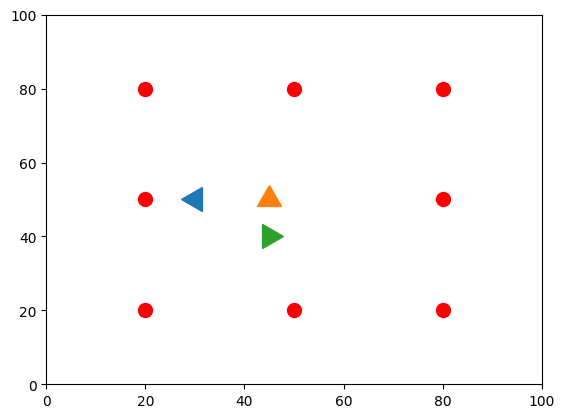

In [36]:
def eval(r, p):
    sum = 0.0;
    for i in range(len(p)): # calculate mean error
        dx = (p[i].x - r.x + (world_size/2.0)) % world_size - (world_size/2.0)
        dy = (p[i].y - r.y + (world_size/2.0)) % world_size - (world_size/2.0)
        err = sqrt(dx * dx + dy * dy)
        sum += err
    return sum / float(len(p))


#### First let's move the robot!
def moveRobot():
    myrobot = robot()
    print ("create myrobot: ", myrobot)
    myrobot.set(30.0, 50.0, pi/2.0)
    positionsX=[]
    positionsY=[]
    orientation=[]

    plt.axis([0, 100, 0, 100])
    positionsX.append(myrobot.x)
    positionsY.append(myrobot.y)
    orientation.append(myrobot.orientation)

    print ("set myrobot: ", myrobot)
    myrobot = myrobot.move(-pi/2.0, 15.0)
    positionsX.append(myrobot.x)
    positionsY.append(myrobot.y)
    orientation.append(myrobot.orientation)

    print ("move: ", myrobot)
    print ("sense: ", myrobot.sense())
    myrobot = myrobot.move(-pi/2.0, 10.0)
    positionsX.append(myrobot.x)
    positionsY.append(myrobot.y)
    orientation.append(myrobot.orientation)

    print ("move: ", myrobot)
    print ("sense: ", myrobot.sense())
    for i in range(len(positionsX)):
      plt.plot(positionsX[i], positionsY[i], marker=(3, 0, orientation[i]* 180 / pi), markersize=20, linestyle='None')

    for l in landmarks:
      plt.scatter(l[0], l[1],color='red', s=100)

    plt.show()


moveRobot()

move:  [x=30.0 y=50.0 orient=1.5707]
move:  [x=37.543 y=49.706 orient=6.2443]
move:  [x=37.348 y=42.796 orient=4.6842]


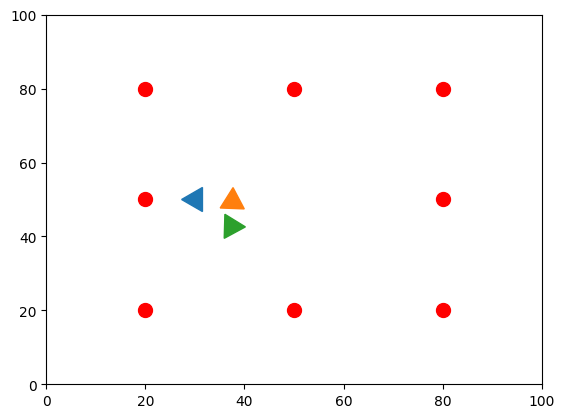

In [37]:
#### The robot can turn and we can model the noise!
def moveRobotTurn():
    positionsX=[]
    positionsY=[]
    orientation=[]
    myrobot = robot()
    myrobot.set_noise(5.0, 0.1, 5.0)
    myrobot.set(30.0, 50.0, pi/2)
    positionsX.append(myrobot.x)
    positionsY.append(myrobot.y)
    orientation.append(myrobot.orientation)
    plt.axis([0, 100, 0, 100])
    print ("move: ", myrobot)

    myrobot = myrobot.move(-pi/2, 15.0)
    print ("move: ", myrobot)
    #print (myrobot.sense())
    positionsX.append(myrobot.x)
    positionsY.append(myrobot.y)
    orientation.append(myrobot.orientation)

    myrobot = myrobot.move(-pi/2, 10.0)
    #print (myrobot.sense())
    print ("move: ", myrobot)
    positionsX.append(myrobot.x)
    positionsY.append(myrobot.y)
    orientation.append(myrobot.orientation)

    for i in range(len(positionsX)):
      plt.plot(positionsX[i], positionsY[i], marker=(3, 0, orientation[i]* 180 / pi), markersize=20, linestyle='None')
    for l in landmarks:
        plt.scatter(l[0], l[1],color='red', s=100)
    plt.show()

moveRobotTurn()


In [38]:
def visualization(robot, step, p, pr, weights):
    '''
    :param robot:   the current robot object
    :param step:    the current step
    :param p:       list with particles
    :param pr:      list of resampled particles
    :param weights: particle weights
    '''
    plt.figure("Robot in the world ", figsize=(15., 15.))
    # draw coordinate grid for plotting
    grid = [0, world_size, 0, world_size]
    plt.axis(grid)
    #plt.grid(b=True, which='major', color='0.75', linestyle='--')
    plt.xticks([i for i in range(0, int(world_size), 5)])
    plt.yticks([i for i in range(0, int(world_size), 5)])

    # Trova l'indice della particella con il peso massimo
    max_weight_index = weights.index(max(weights))

    # draw particles
    for ind in range(len(p)):

        if ind == max_weight_index:
            # Disegna la particella con il peso massimo in rosso
            circle = plt.Circle((p[ind].x, p[ind].y), 2., facecolor='#050505', edgecolor='#050505', alpha=0.7) # black
            arrow = plt.Arrow(p[ind].x, p[ind].y, 2*cos(p[ind].orientation), 2*sin(p[ind].orientation), alpha=1., facecolor='#cc0000', edgecolor='#cc0000')
        else:
            # Disegna tutte le altre particelle
            circle = plt.Circle((p[ind].x, p[ind].y), 1., facecolor='#ffb266', edgecolor='#994c00', alpha=0.5) # yellow
            arrow = plt.Arrow(p[ind].x, p[ind].y, 2*cos(p[ind].orientation), 2*sin(p[ind].orientation), alpha=1., facecolor='#994c00', edgecolor='#994c00')

        plt.gca().add_patch(circle)
        plt.gca().add_patch(arrow)

    # draw resampled particles
    for ind in range(len(pr)):

        # particle
        circle = plt.Circle((pr[ind].x, pr[ind].y), 1., facecolor='#66ff66', edgecolor='#009900', alpha=0.5) # green
        plt.gca().add_patch(circle)

        # particle's orientation
        arrow = plt.Arrow(pr[ind].x, pr[ind].y, 2*cos(pr[ind].orientation), 2*sin(pr[ind].orientation), alpha=1., facecolor='#006600', edgecolor='#006600')
        plt.gca().add_patch(arrow)

    # fixed landmarks of known locations
    for lm in landmarks:
        circle = plt.Circle((lm[0], lm[1]), 1., facecolor='#cc0000', edgecolor='#330000')
        plt.gca().add_patch(circle)

    # robot's location
    circle = plt.Circle((robot.x, robot.y), 1., facecolor='#6666ff', edgecolor='#0000cc') # blue
    plt.gca().add_patch(circle)

    # robot's orientation
    arrow = plt.Arrow(robot.x, robot.y, 2*cos(robot.orientation), 2*sin(robot.orientation), alpha=0.5, facecolor='#000000', edgecolor='#000000')
    plt.gca().add_patch(arrow)

    #plt.savefig("figure_" + str(step) + ".png")
    plt.show()
    #plt.close()

100
[[x=92.560 y=4.6268 orient=3.5516], [x=34.630 y=0.6628 orient=1.9565], [x=77.580 y=42.236 orient=0.4051], [x=62.918 y=46.977 orient=3.4011], [x=12.325 y=21.057 orient=5.9753], [x=38.034 y=93.574 orient=0.9805], [x=55.043 y=92.110 orient=2.2231], [x=38.699 y=97.972 orient=3.5625], [x=81.279 y=46.834 orient=3.6851], [x=52.582 y=41.924 orient=0.3051], [x=78.704 y=3.6601 orient=3.6893], [x=38.872 y=98.497 orient=2.5049], [x=97.438 y=33.019 orient=0.9937], [x=68.595 y=66.438 orient=5.4549], [x=85.992 y=21.550 orient=1.8316], [x=46.381 y=4.3660 orient=5.2822], [x=31.506 y=89.781 orient=1.1901], [x=20.501 y=88.925 orient=1.3887], [x=27.030 y=21.773 orient=0.1584], [x=98.521 y=73.162 orient=0.9479], [x=70.260 y=36.251 orient=2.8570], [x=31.073 y=60.763 orient=5.0809], [x=88.818 y=22.939 orient=3.8636], [x=85.801 y=90.160 orient=3.5213], [x=10.563 y=69.719 orient=1.2081], [x=8.7639 y=29.438 orient=0.1249], [x=68.245 y=44.507 orient=1.3511], [x=53.719 y=63.003 orient=4.1781], [x=61.064 y=83.

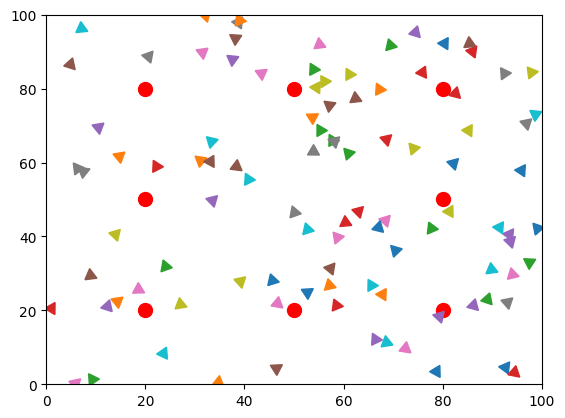

In [39]:

# We define multiples particles as a robot representation
def createParticlesTest():
    N = 100
    p = []
    plt.axis([0, 100, 0, 100])

    for i in range(N):
        p.append(robot())
    print (len(p))
    print (p)

    for i in range(N):
      plt.plot(p[i].x, p[i].y, marker=(3, 0, p[i].orientation* 180 / pi), markersize=10, linestyle='None')

    for l in landmarks:
        plt.scatter(l[0], l[1],color='red', s=100)

    plt.show()

createParticlesTest()

[5.068860606075464e-47, 1.723113406059877e-19, 7.343487584661676e-18, 7.525573098176665e-66, 1.9741349045220356e-85, 1.4161941082199055e-64, 6.431822660491768e-19, 1.3652827285392384e-09, 9.944120204802273e-55, 9.137782731574861e-66]


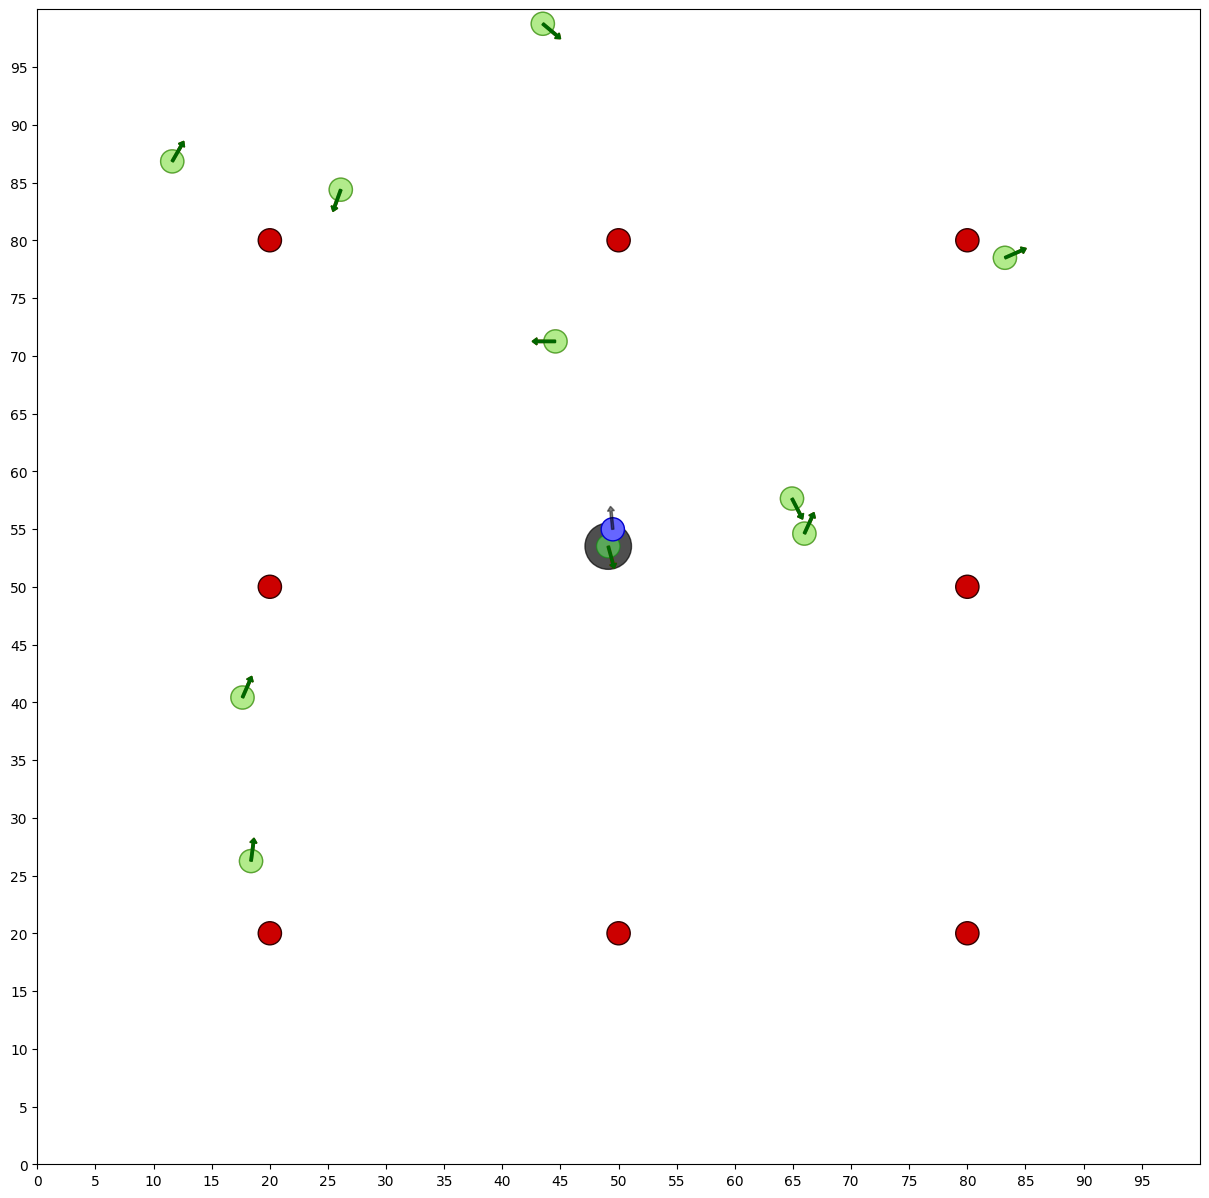

[9.241546798357056e-44, 3.7744991092916674e-16, 1.4093354151251073e-23, 1.3078753264936608e-47, 3.2274935052004144e-80, 6.197173393792882e-71, 8.277793304779331e-22, 6.553652575184927e-14, 7.05835754207635e-42, 6.2386891125370995e-62]


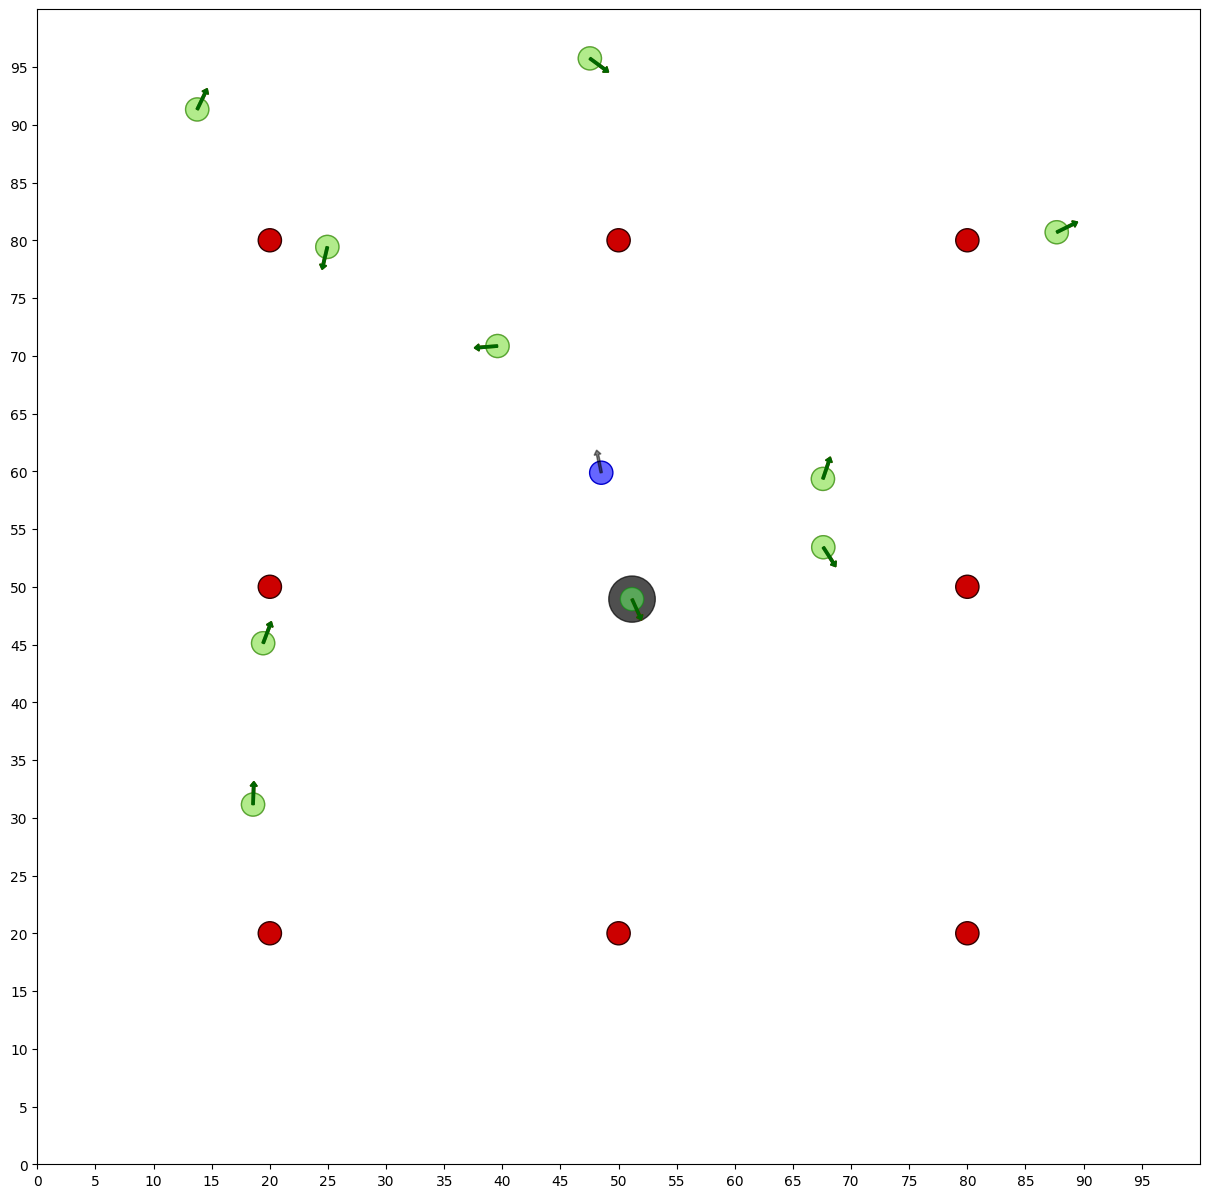

[3.000841904548707e-41, 1.331594756663952e-15, 4.3875295418860276e-36, 3.1566693478705753e-34, 2.95943655137636e-77, 3.6758257424006466e-81, 1.0092901191955668e-24, 7.368150190041691e-25, 1.2868296402319126e-30, 2.347697014693744e-59]


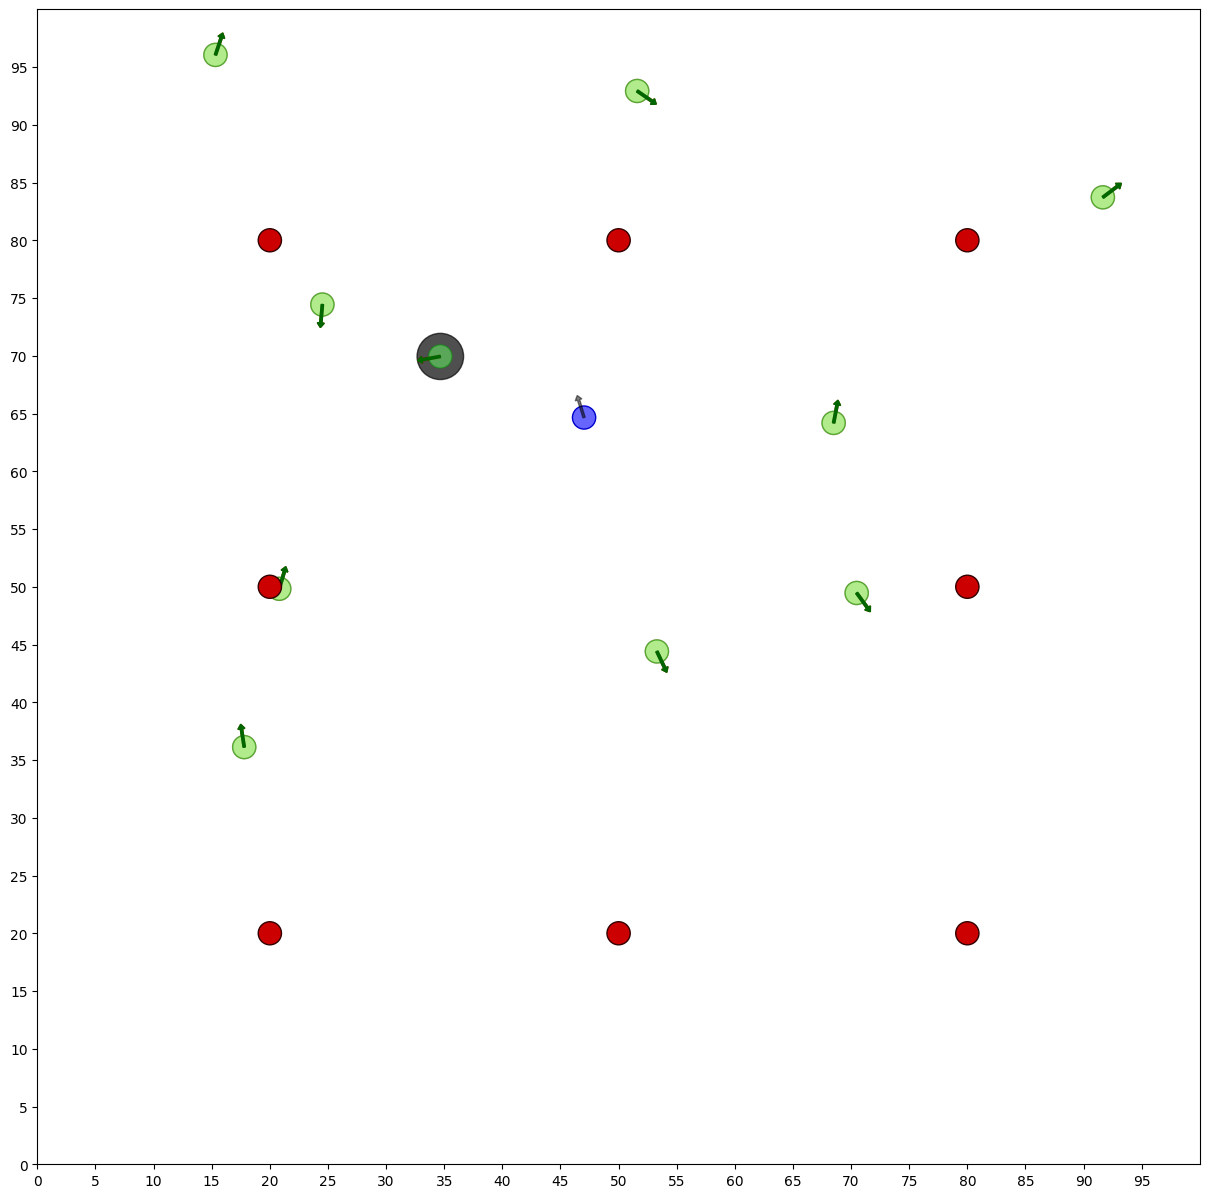

[1.8422696918660003e-35, 1.521169086756956e-17, 2.4512031271793149e-54, 1.076258345186932e-26, 6.334095503286396e-146, 1.1823121758001919e-94, 1.1433943534278633e-27, 1.8948530015701809e-41, 3.8136270612012765e-24, 2.085419679894283e-57]


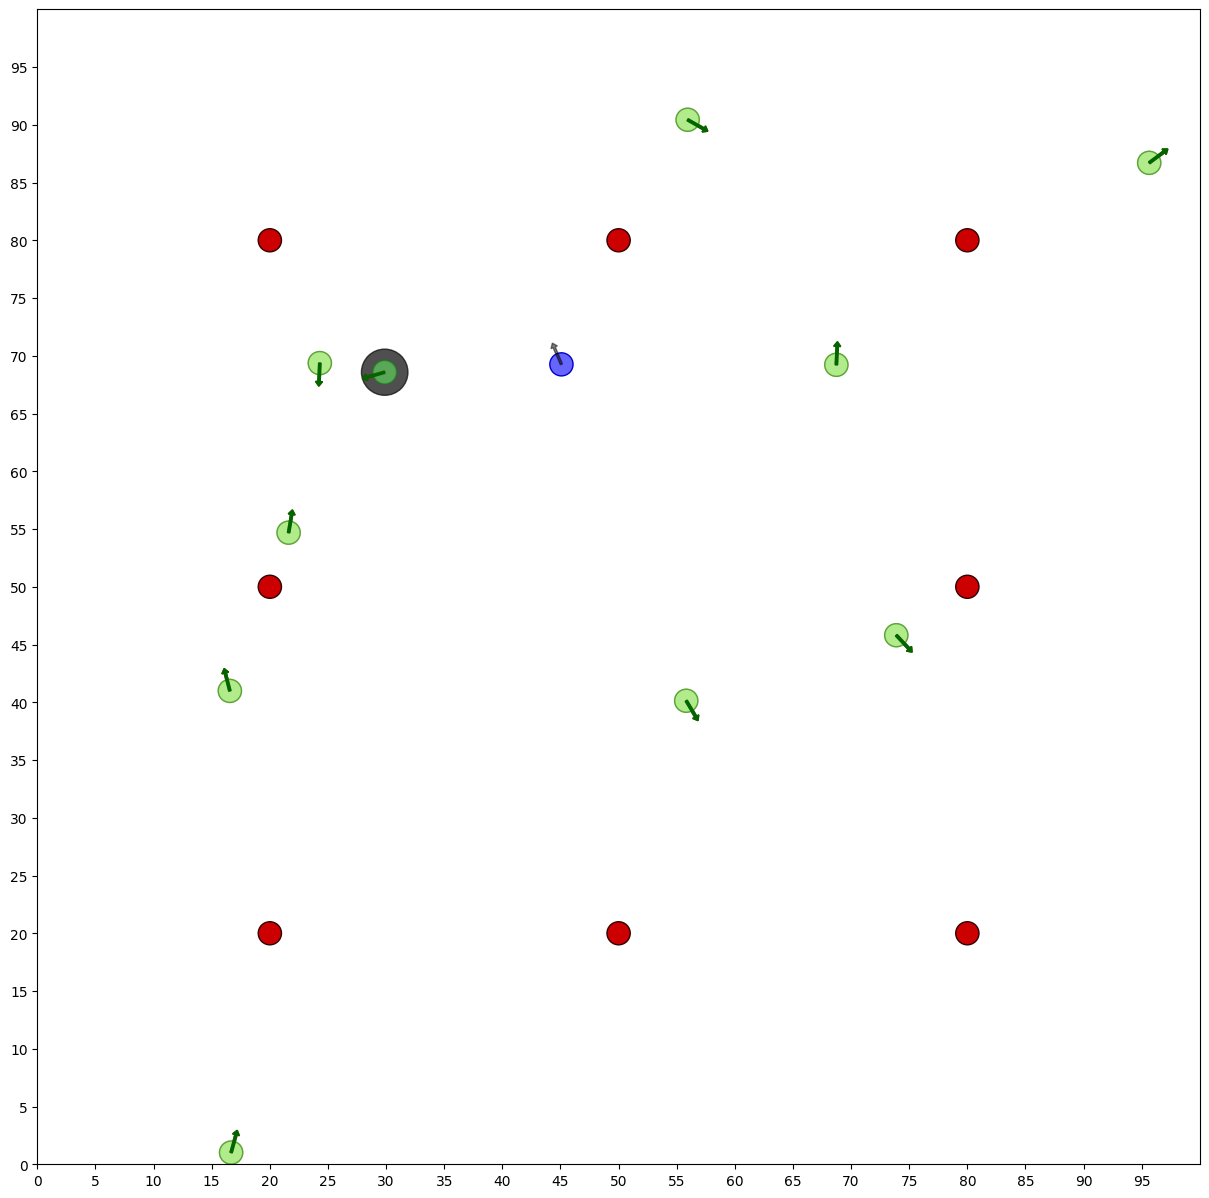

[4.0102505456280345e-30, 4.366030238964847e-21, 5.026667885197735e-75, 8.336899371873249e-26, 4.030793260912842e-136, 1.2681813399538272e-109, 4.31662889251174e-30, 6.337584954992312e-62, 1.1931946906886867e-22, 1.0686816429773867e-54]


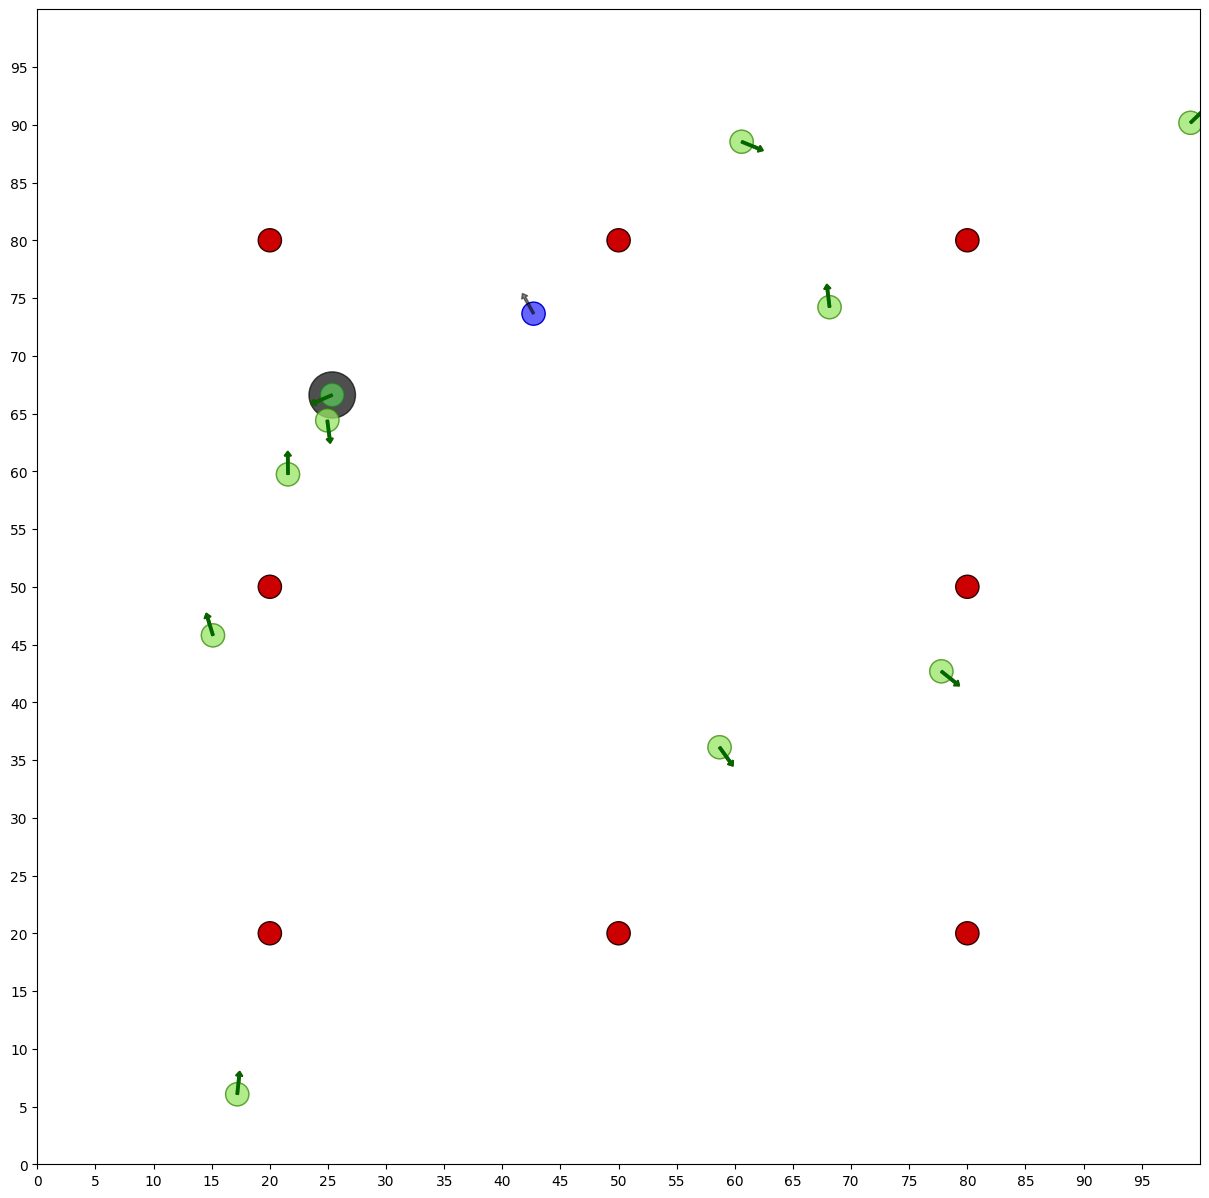

[1.4648052983437194e-24, 1.5204894463129445e-25, 2.378915103241681e-95, 3.2117842637024083e-31, 4.965333190887781e-127, 2.9905961263172734e-72, 5.03158178158704e-32, 6.767293218543724e-84, 2.522630749354075e-26, 6.696577392903299e-50]


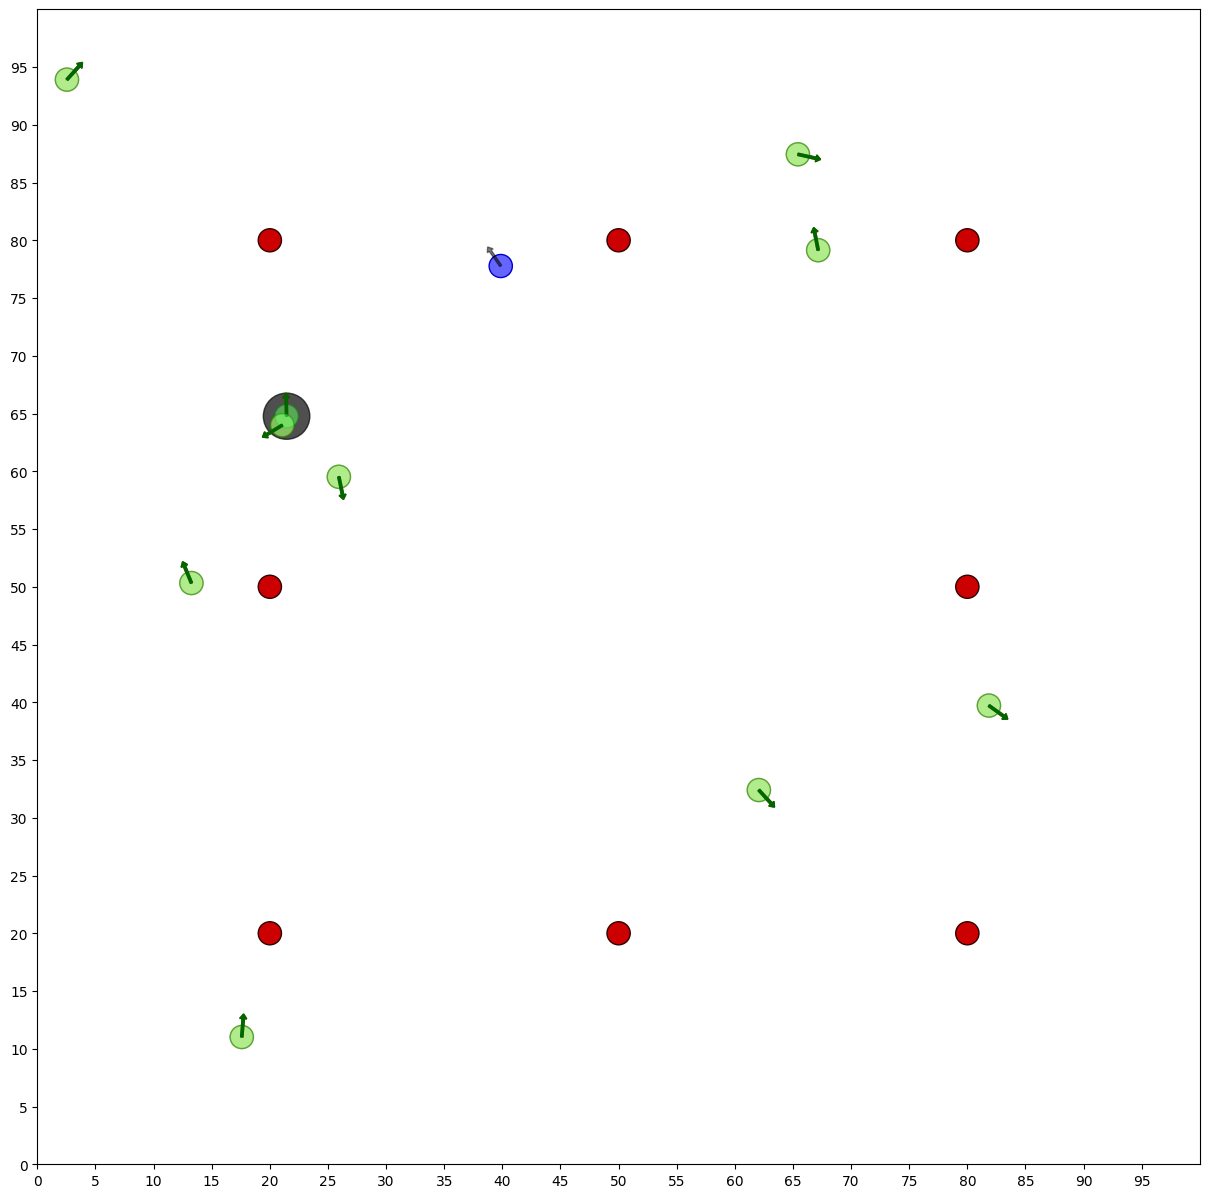

[1.3756908863271647e-19, 1.299850704762465e-30, 3.0974509269799228e-114, 2.2325321567916293e-41, 4.089412029838382e-119, 3.1955103423117844e-61, 7.249275045529715e-33, 5.634083925871905e-106, 5.210844342257292e-34, 3.516309993810801e-43]


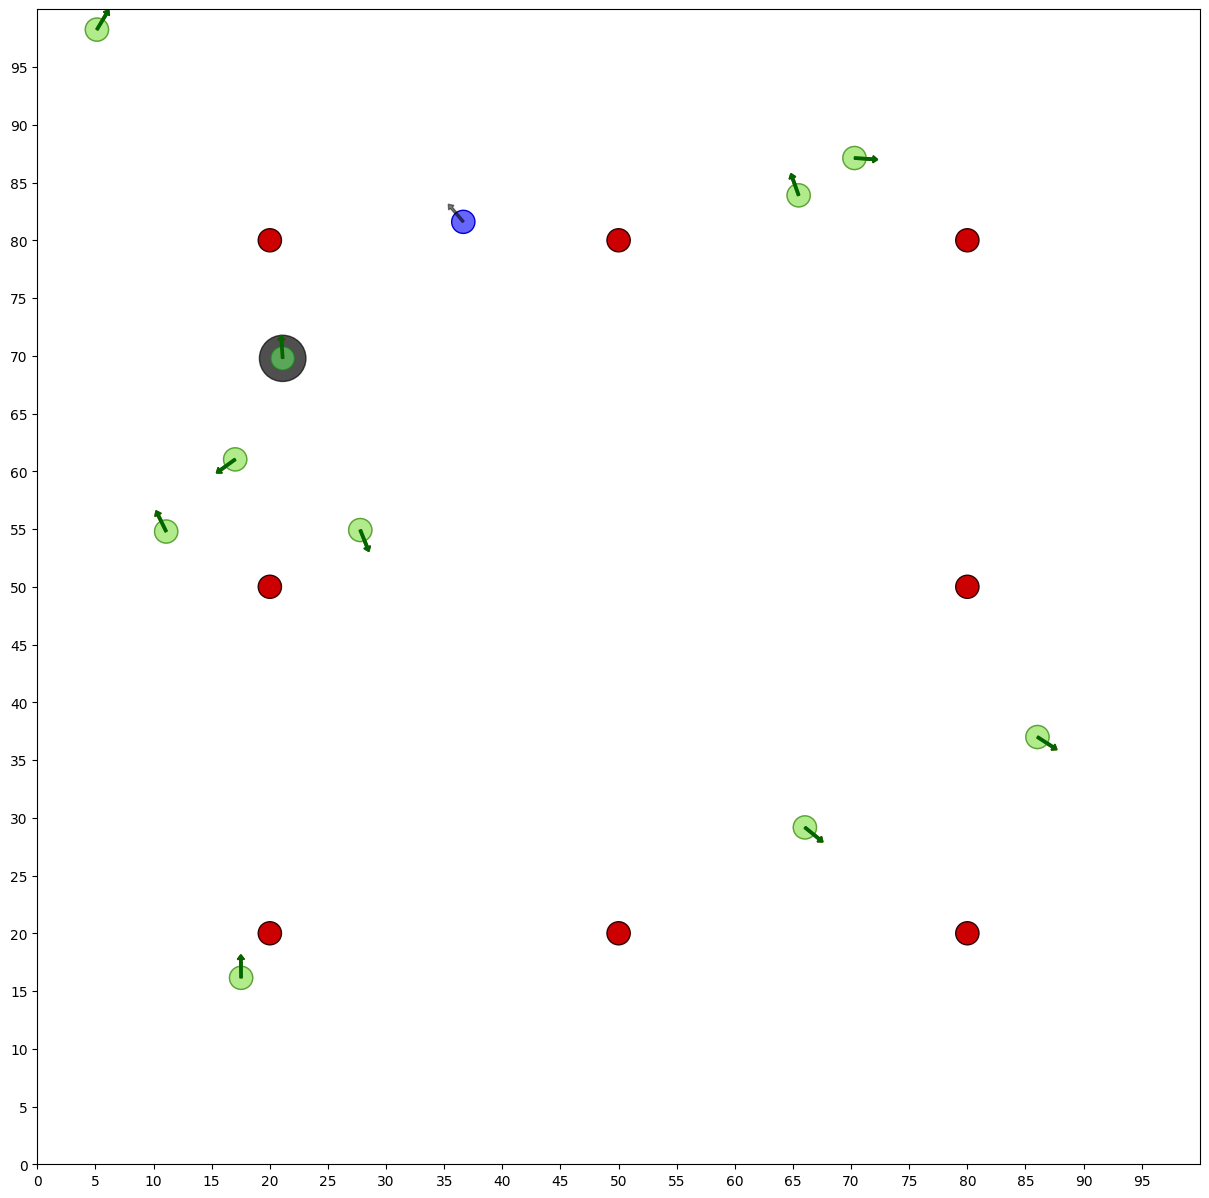

[2.9317868105633924e-16, 3.973665991068391e-36, 2.6626976979764575e-131, 6.373473221700185e-55, 6.5403242649579644e-111, 1.9396491086679984e-148, 5.49921125646342e-34, 4.1092976190537154e-128, 1.629423501256764e-45, 2.8983949026075673e-37]


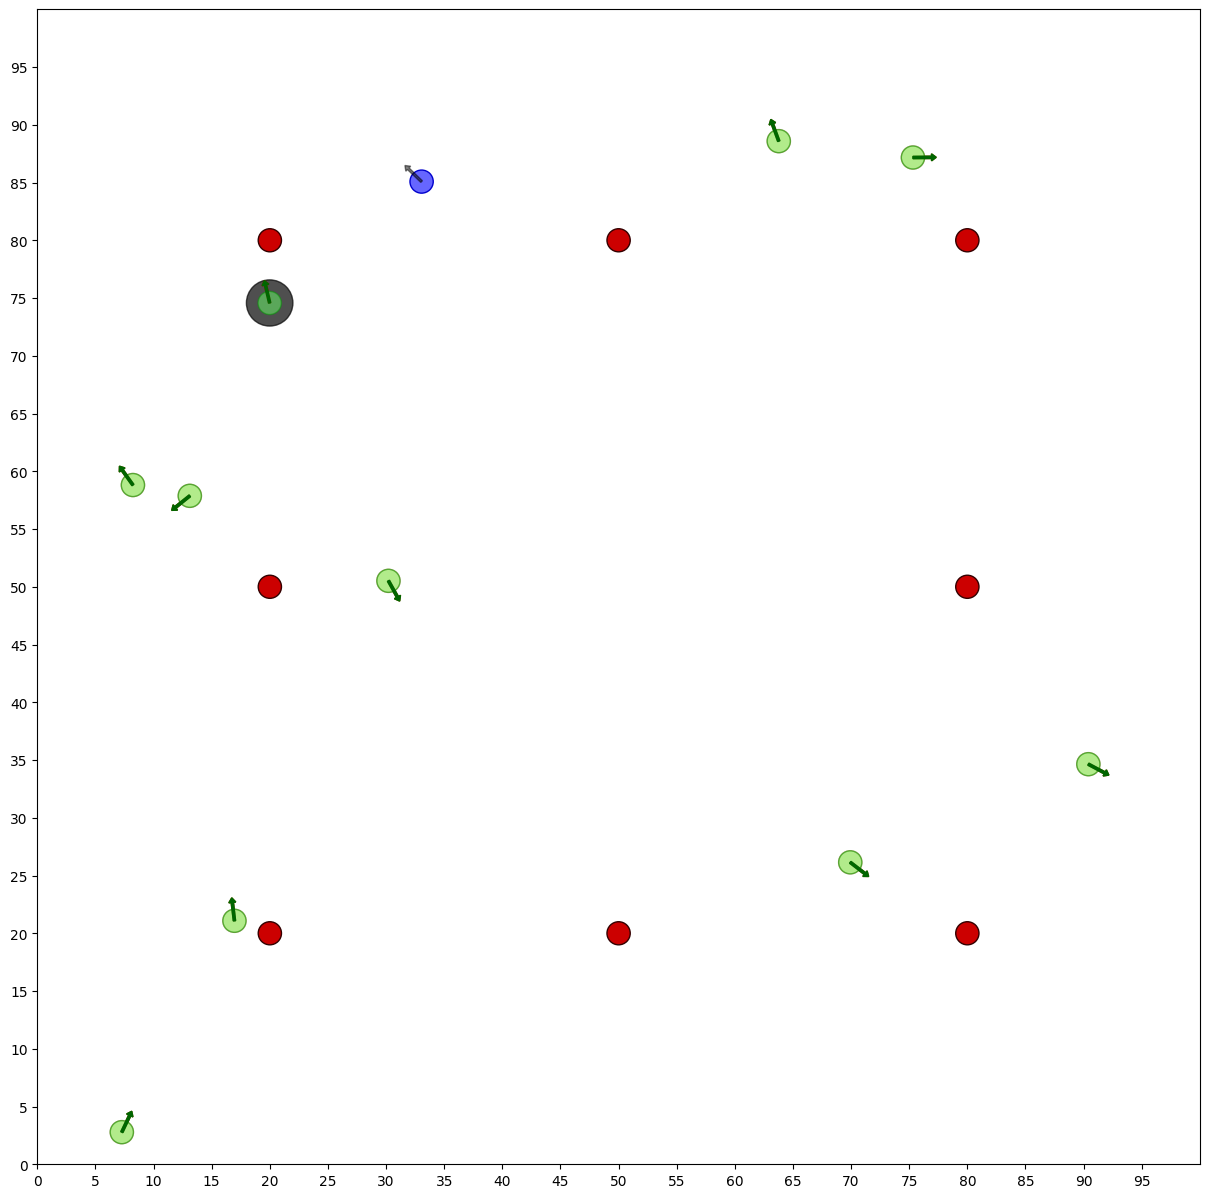

[3.9627505288670937e-14, 3.4561282752181154e-42, 8.14405763446883e-146, 1.1581623518612053e-68, 4.538547185963158e-99, 3.852580444154384e-131, 1.280254456709995e-34, 1.3380568300078802e-150, 9.99268696231222e-61, 1.1745309927136108e-32]


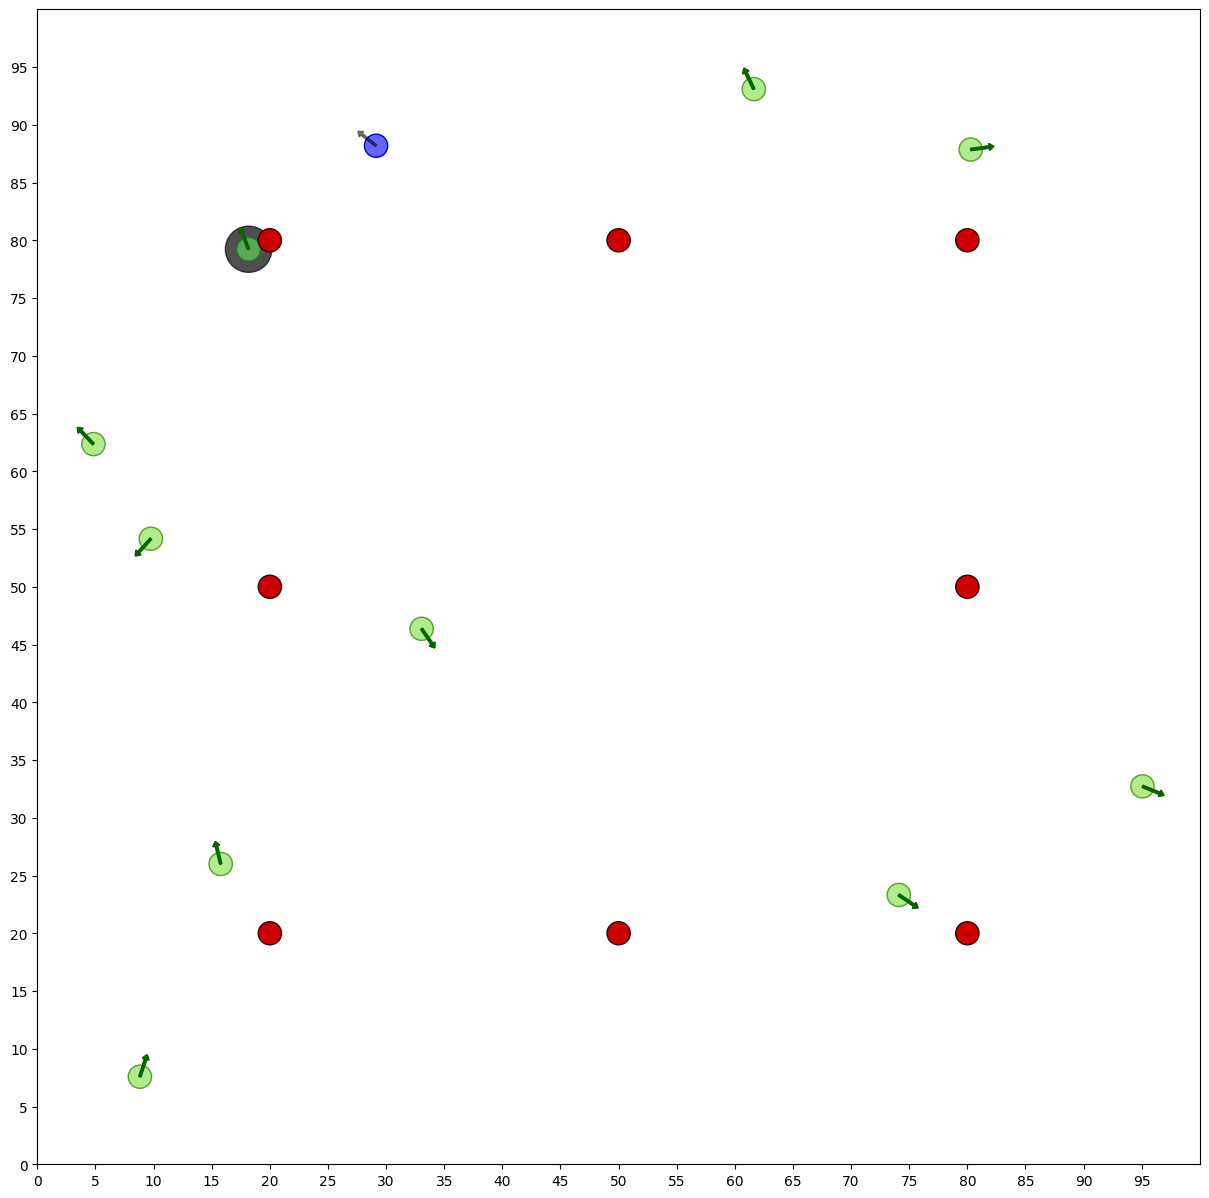

[5.82081088770253e-12, 6.095522350677837e-48, 1.2484678231358077e-156, 4.502033449182847e-80, 1.7024095465332284e-88, 8.997423185378615e-119, 7.94596784976354e-35, 1.975716146388656e-172, 2.8934904050251333e-79, 1.1719821969786953e-28]


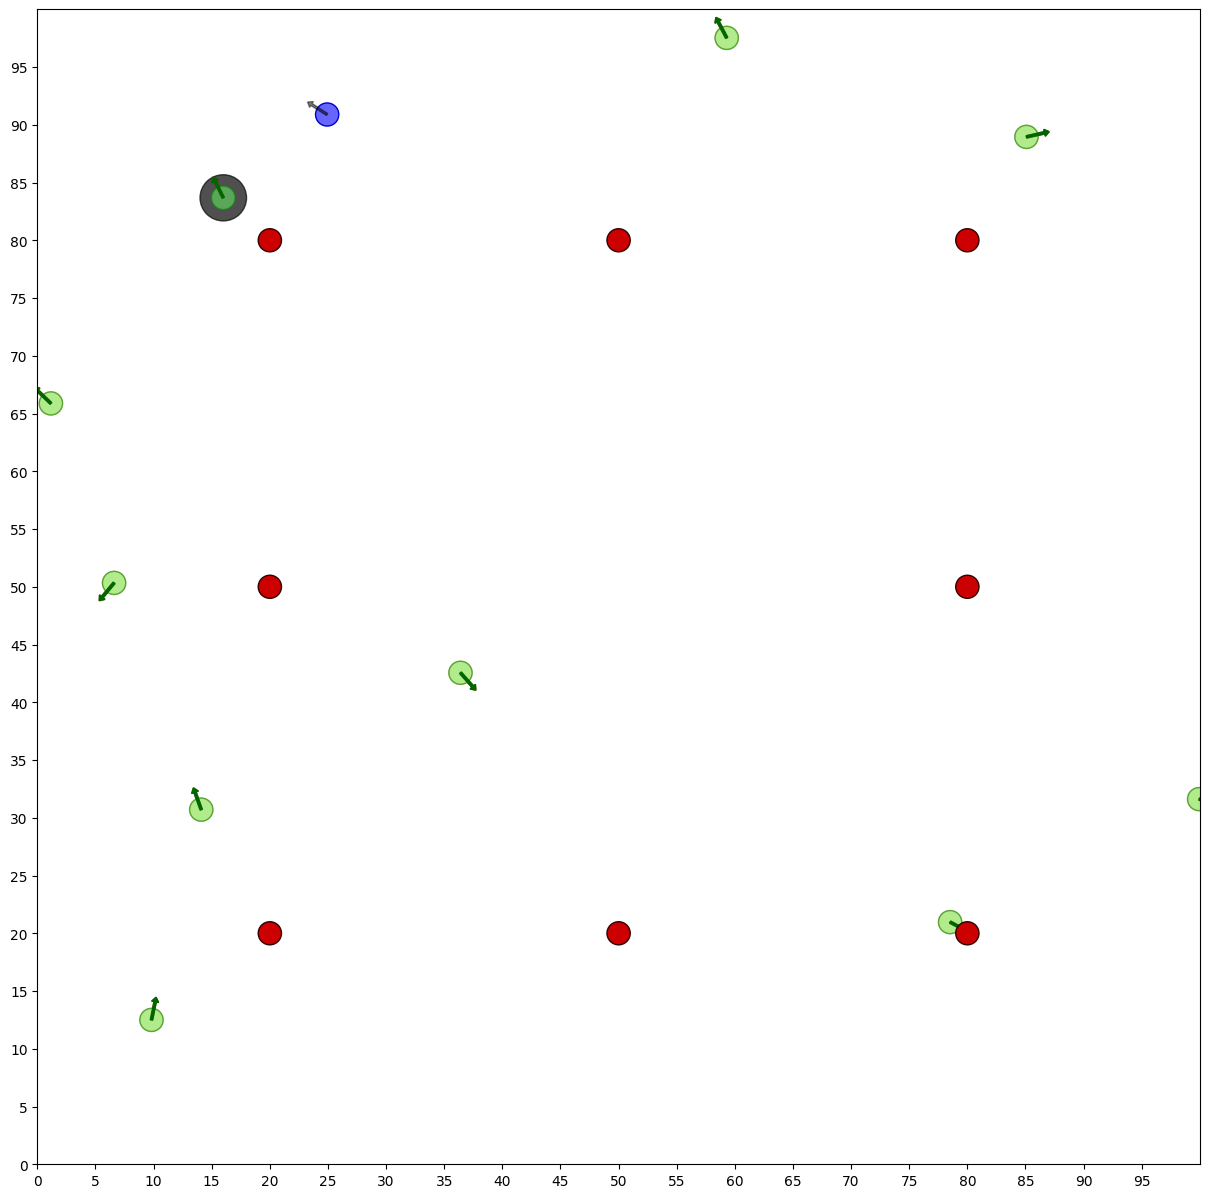

[1.354796333510803e-10, 2.7754806457147906e-53, 5.888238916417053e-81, 3.5135201218830224e-89, 1.2512543078598e-79, 7.668000961454549e-110, 3.084440427047835e-160, 1.7243449525492078e-182, 2.415145302558373e-100, 1.7878453010451618e-113]


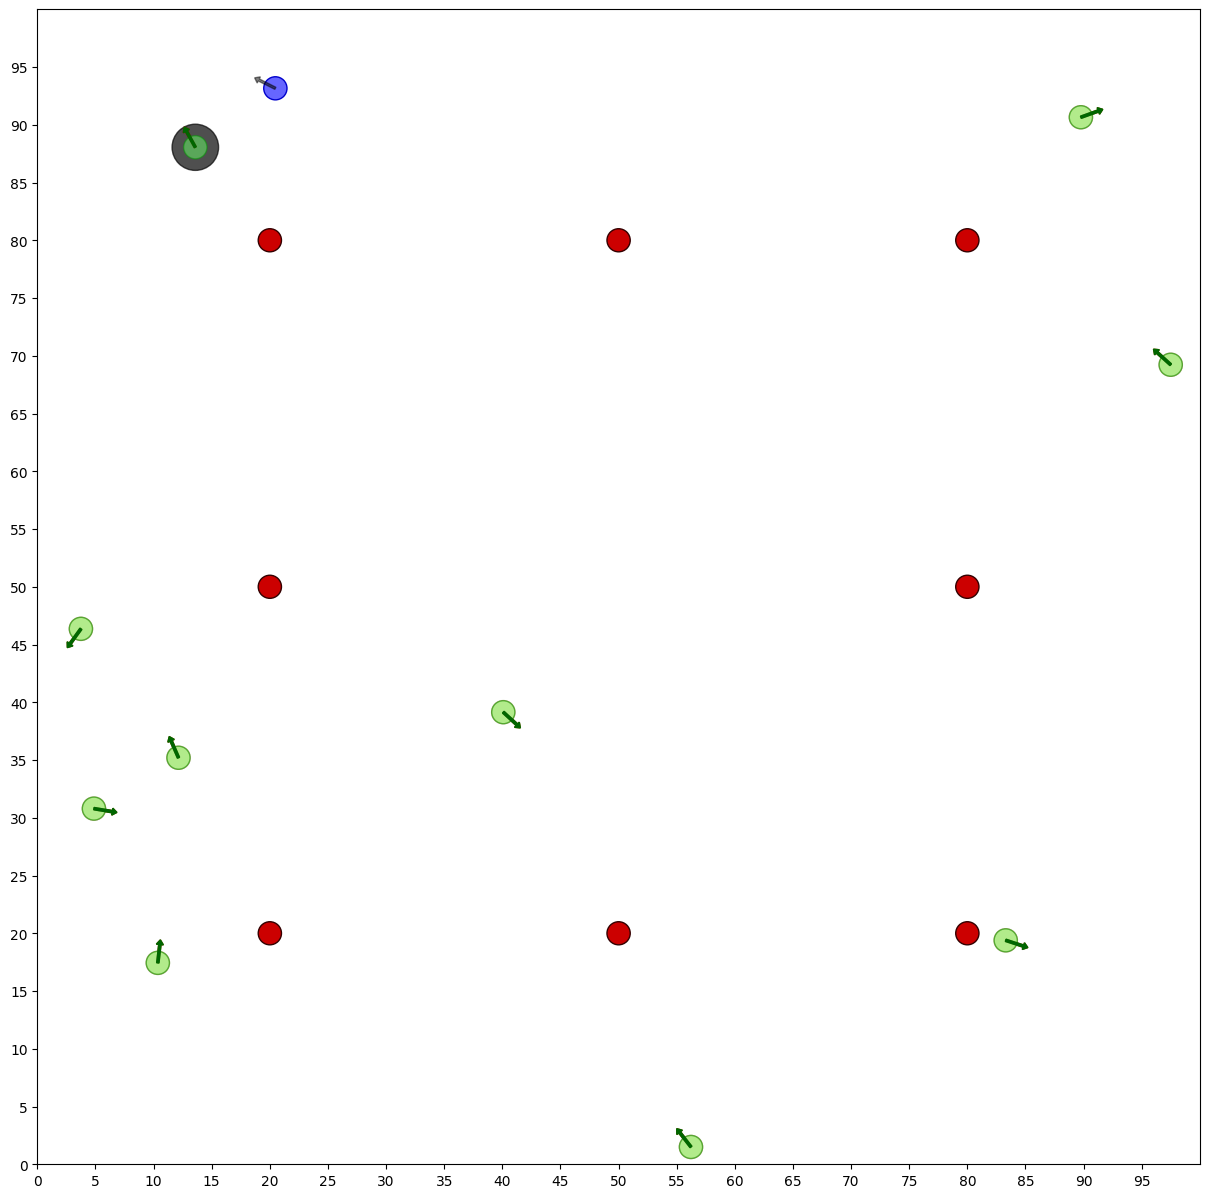

[6.005451187925769e-10, 6.7111190054235255e-59, 6.570784242766362e-88, 2.645326066850413e-96, 7.810448953854911e-72, 7.543936359709885e-102, 1.3339515875473836e-160, 2.2826147090512876e-185, 5.1592181828852244e-123, 2.7350128263434486e-115]


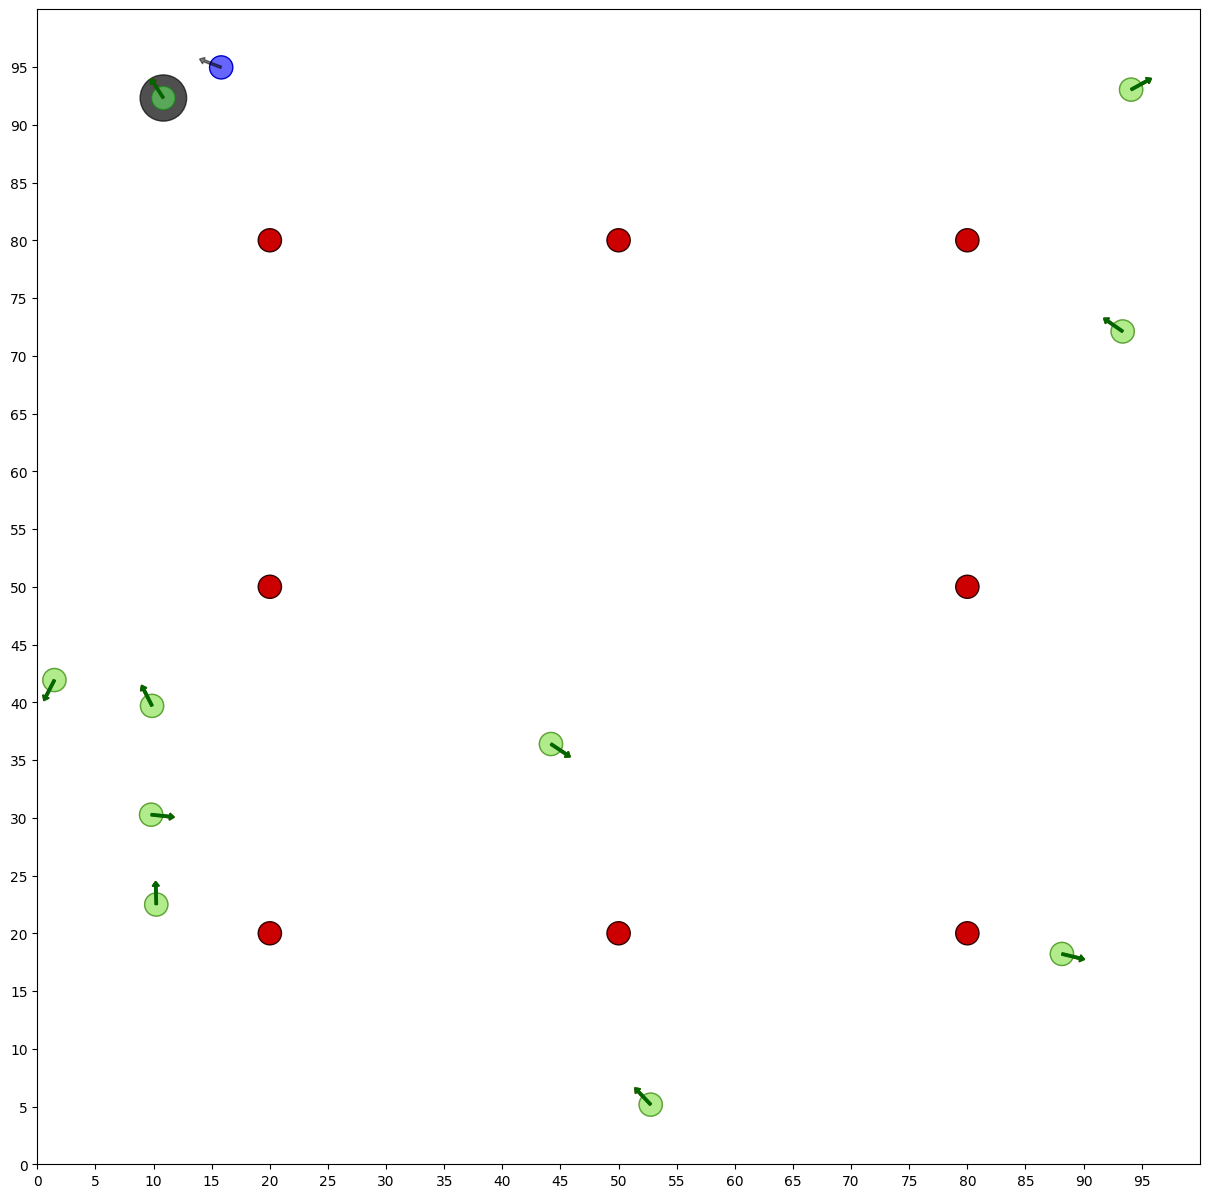

[8.638310920831576e-10, 2.1156294195002595e-165, 1.6989413896374126e-100, 1.5748842746071228e-102, 9.442825134343606e-65, 2.403955976493441e-94, 9.533072785156193e-164, 8.325849465220345e-187, 3.285678213283383e-147, 7.738875392649482e-121]


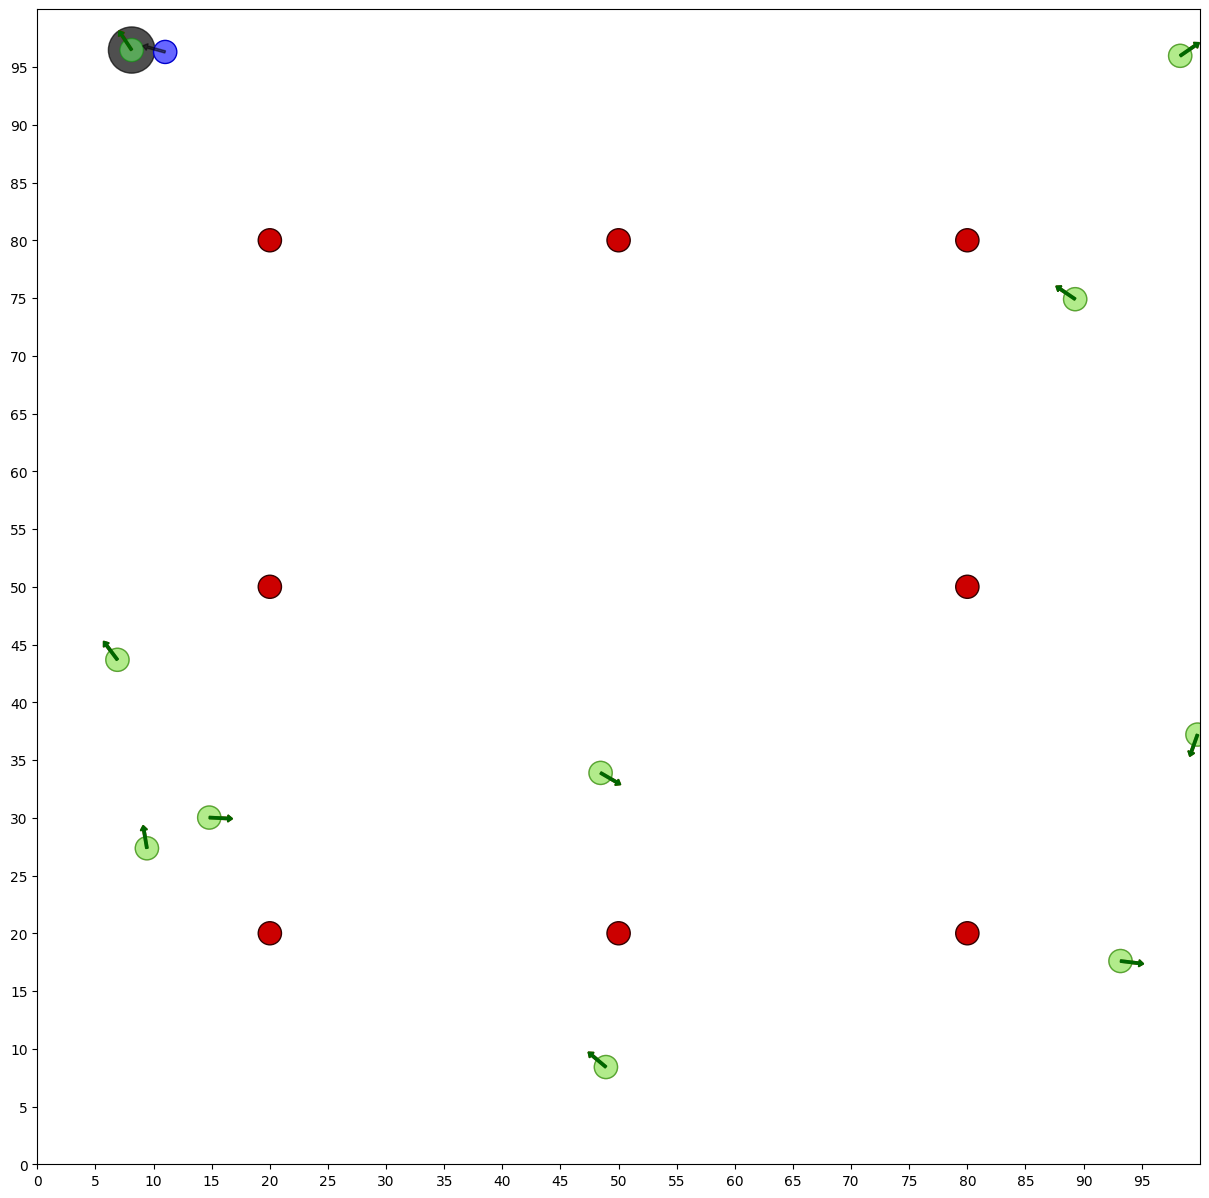

[8.97684716611056e-113, 9.27674022367653e-178, 1.3548550833927843e-116, 1.592799541012392e-10, 5.4562948480852836e-58, 6.820288558173185e-88, 1.633823938564794e-167, 1.5511370994171755e-187, 1.2073993563431193e-171, 1.0248895888560578e-130]


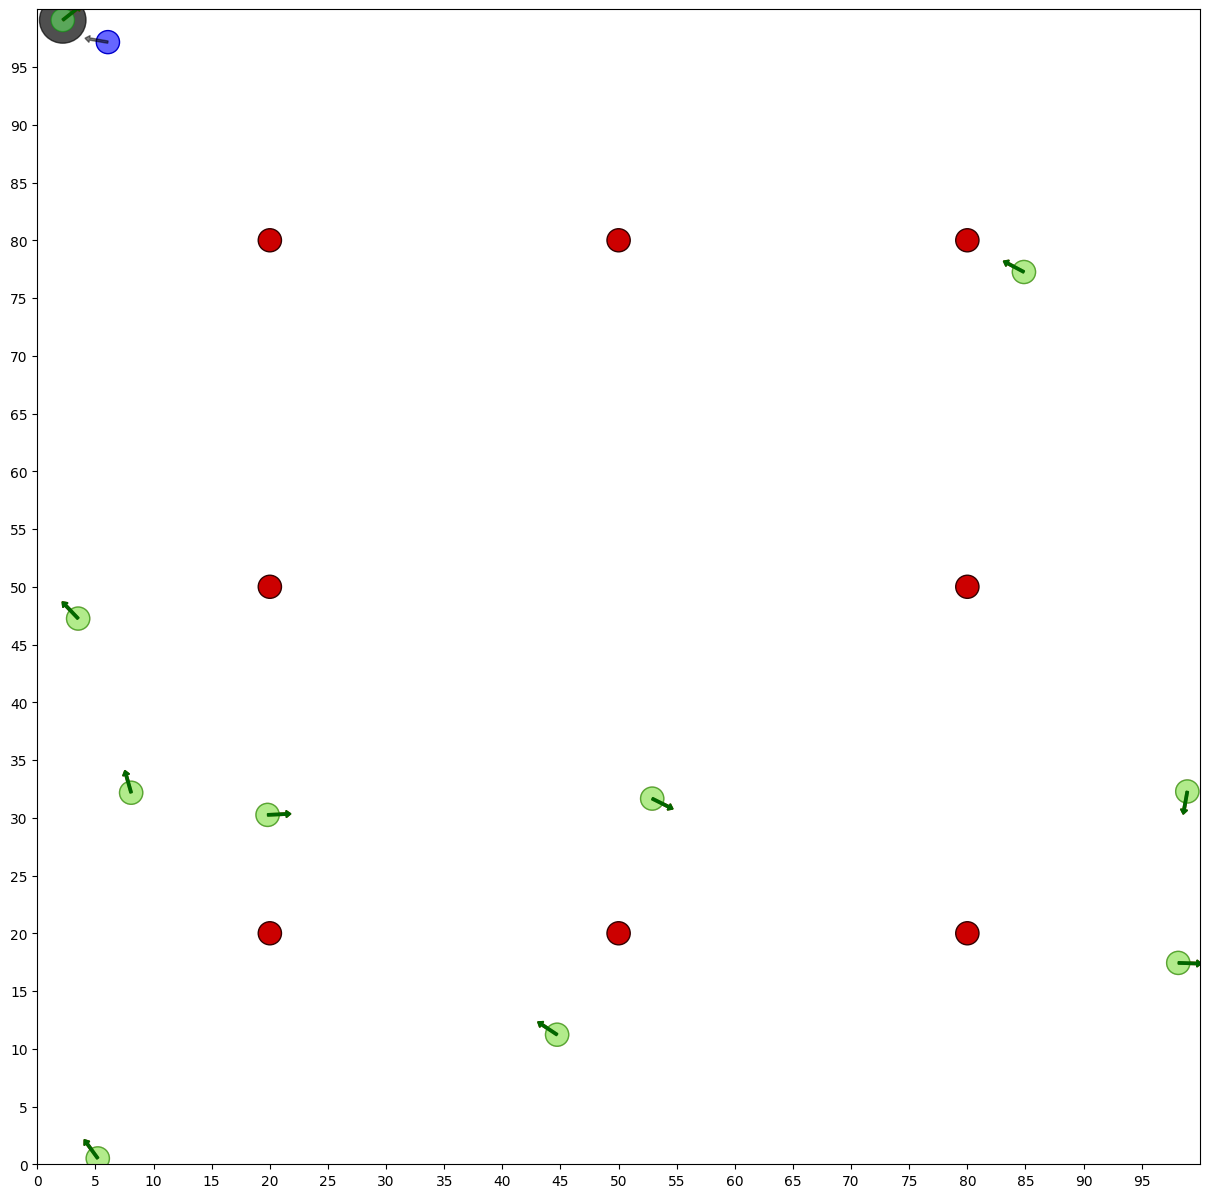

[2.750242484545747e-102, 6.767128268523348e-189, 1.005844916769005e-134, 1.3908949785639046e-107, 1.0075031852980601e-168, 1.4624522797690383e-82, 3.314733519901723e-171, 2.1599224617421307e-95, 1.4851493216737958e-194, 1.5380583716574493e-144]


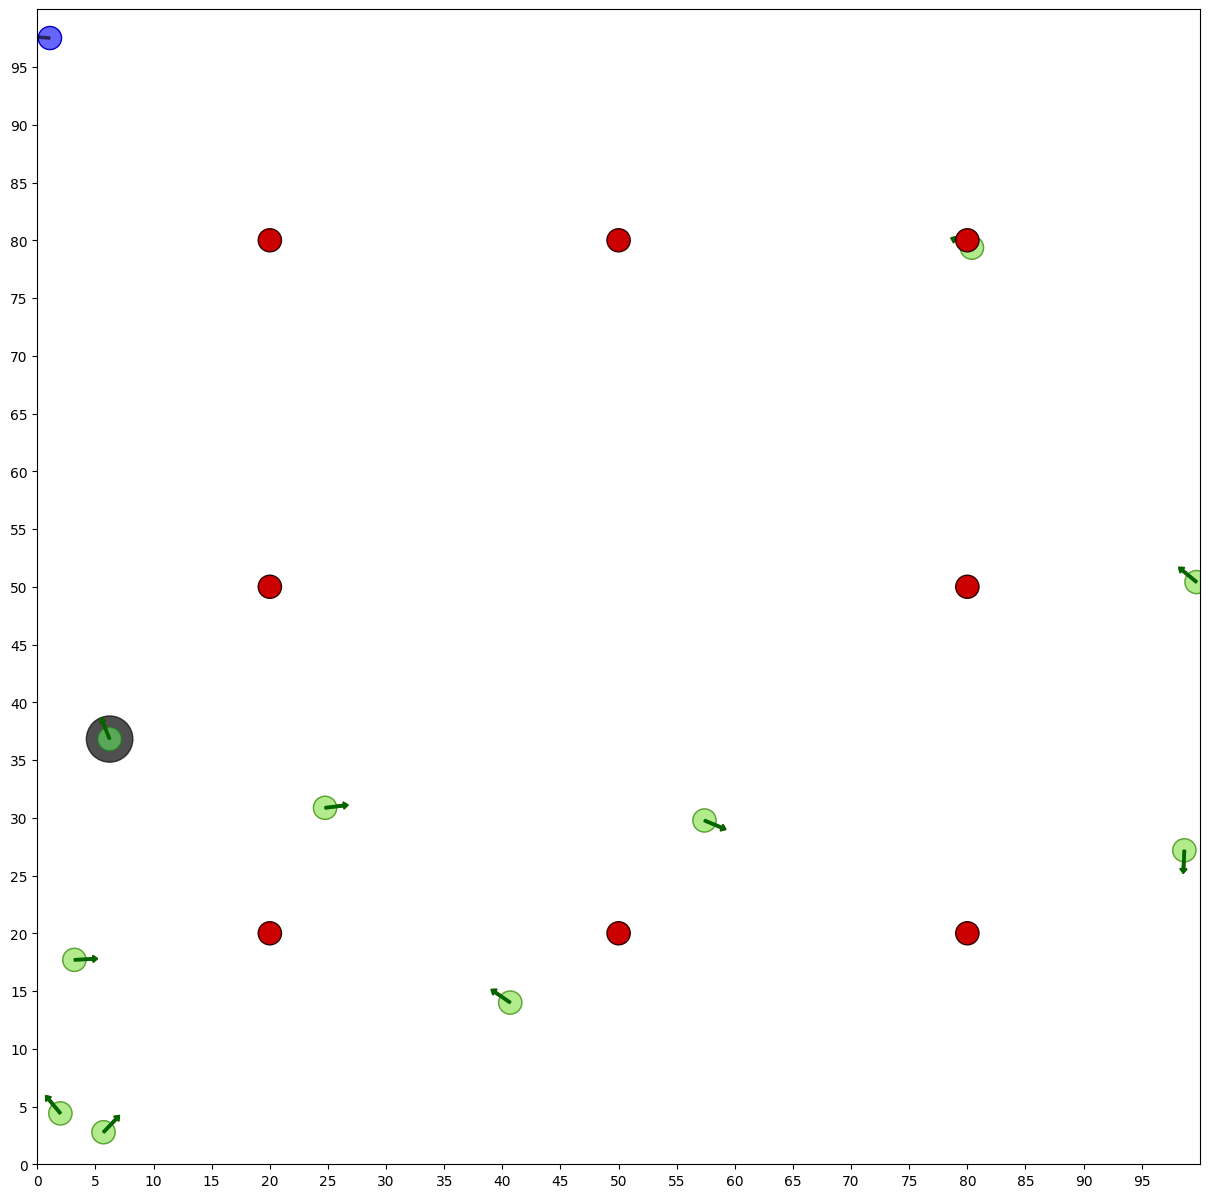

[8.402458028545507e-101, 2.697712792958382e-88, 4.852842243670429e-197, 2.3660123162422936e-192, 6.024317379956444e-53, 7.153752441112356e-177, 5.646390533078653e-196, 1.254035139354564e-196, 2.0365017215069073e-156, 2.0265146727889683e-44]


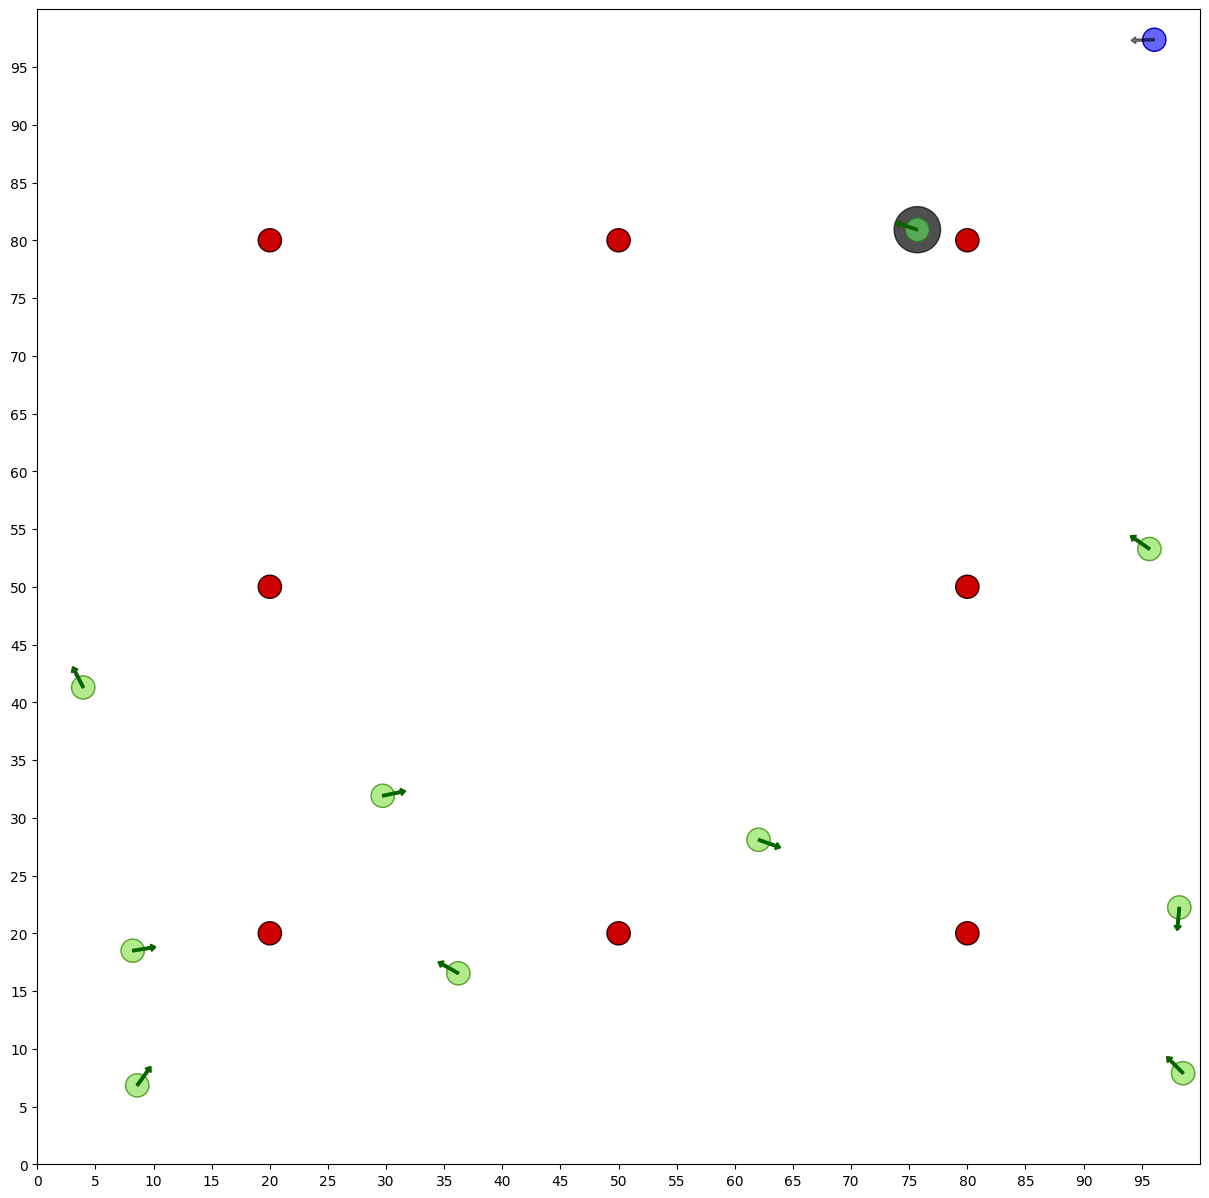

[1.3521362425398379e-105, 5.171275640766522e-94, 8.802591330318054e-176, 1.1105736657376262e-191, 9.945190229095983e-50, 1.6808777441719427e-160, 2.4881340425956445e-190, 4.405596802050794e-196, 1.470366424549591e-138, 1.864253534793117e-38]


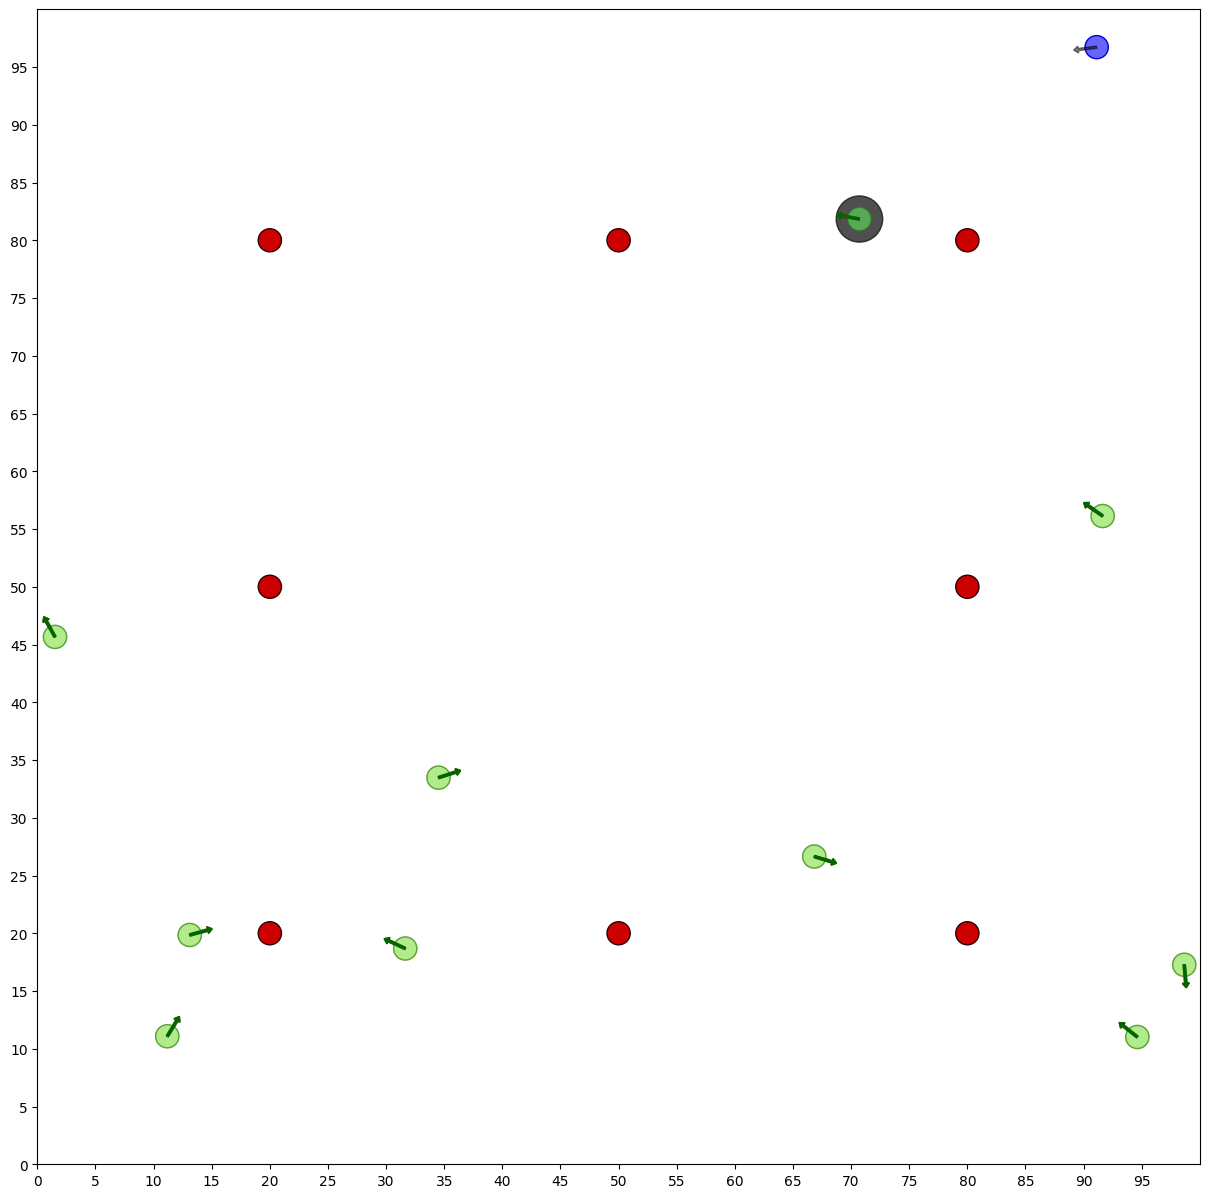

[4.054013545070661e-110, 3.3713982360368887e-103, 2.9484913801552064e-153, 2.3999874634166787e-189, 4.6110482615906664e-46, 1.1991858221608381e-46, 1.039958671525282e-185, 9.731750179586629e-193, 1.036707885024464e-124, 2.427503246648222e-33]


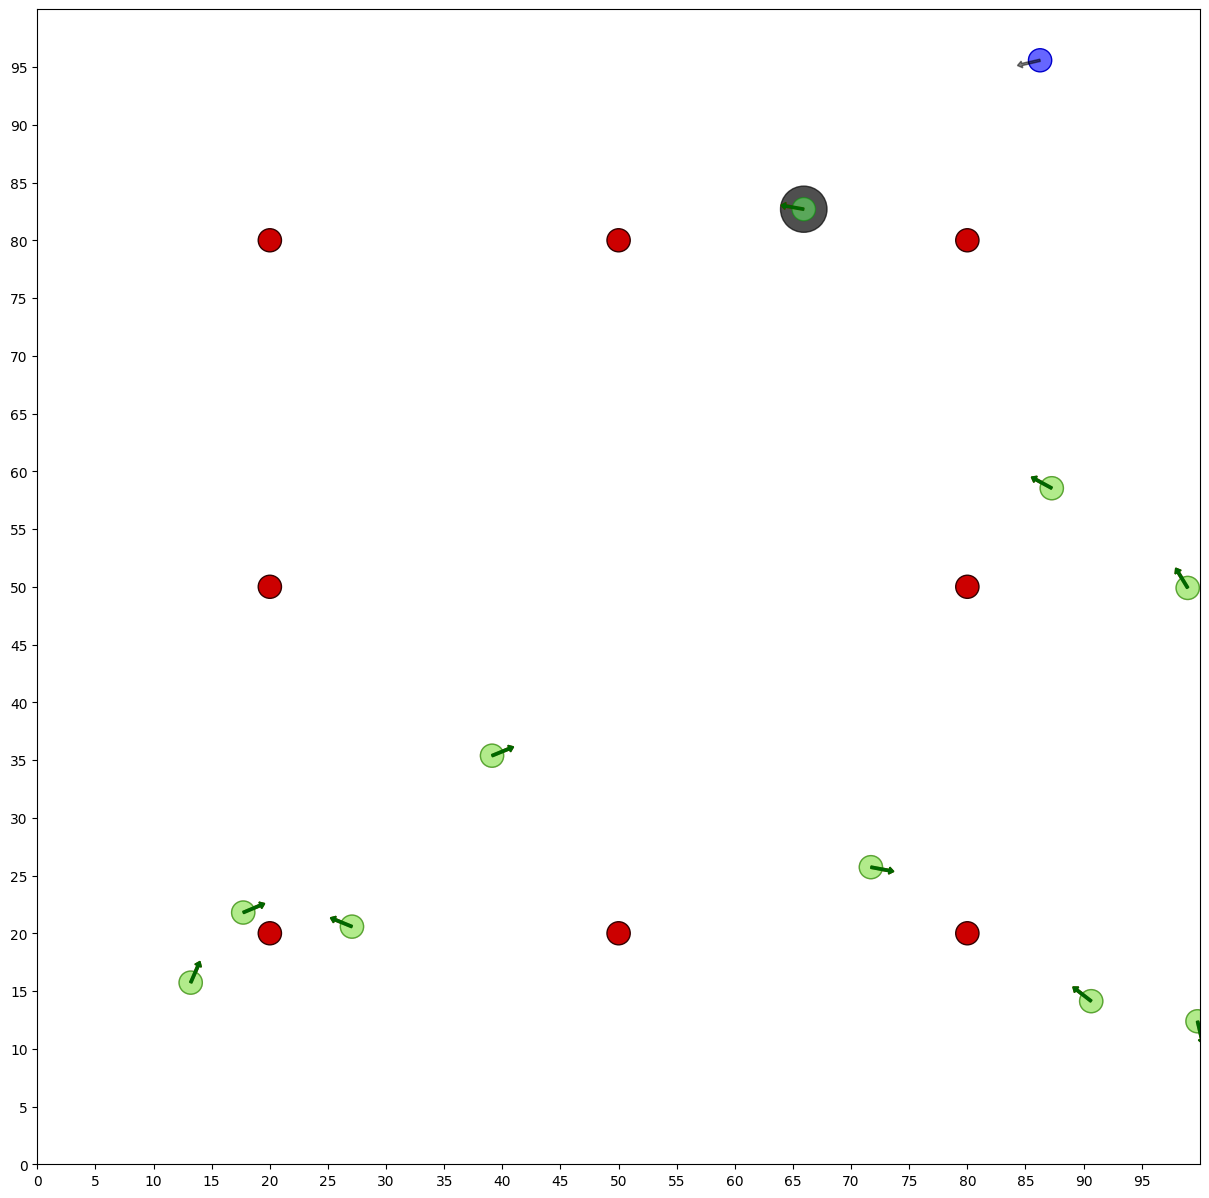

[2.8145576591023227e-115, 1.5650599136915699e-190, 1.996204496306141e-129, 1.4435356921325131e-182, 1.0464576877147923e-42, 8.82451674943044e-42, 2.0422015754589578e-181, 6.125989556428196e-178, 3.758118381959798e-115, 3.854042826104086e-30]


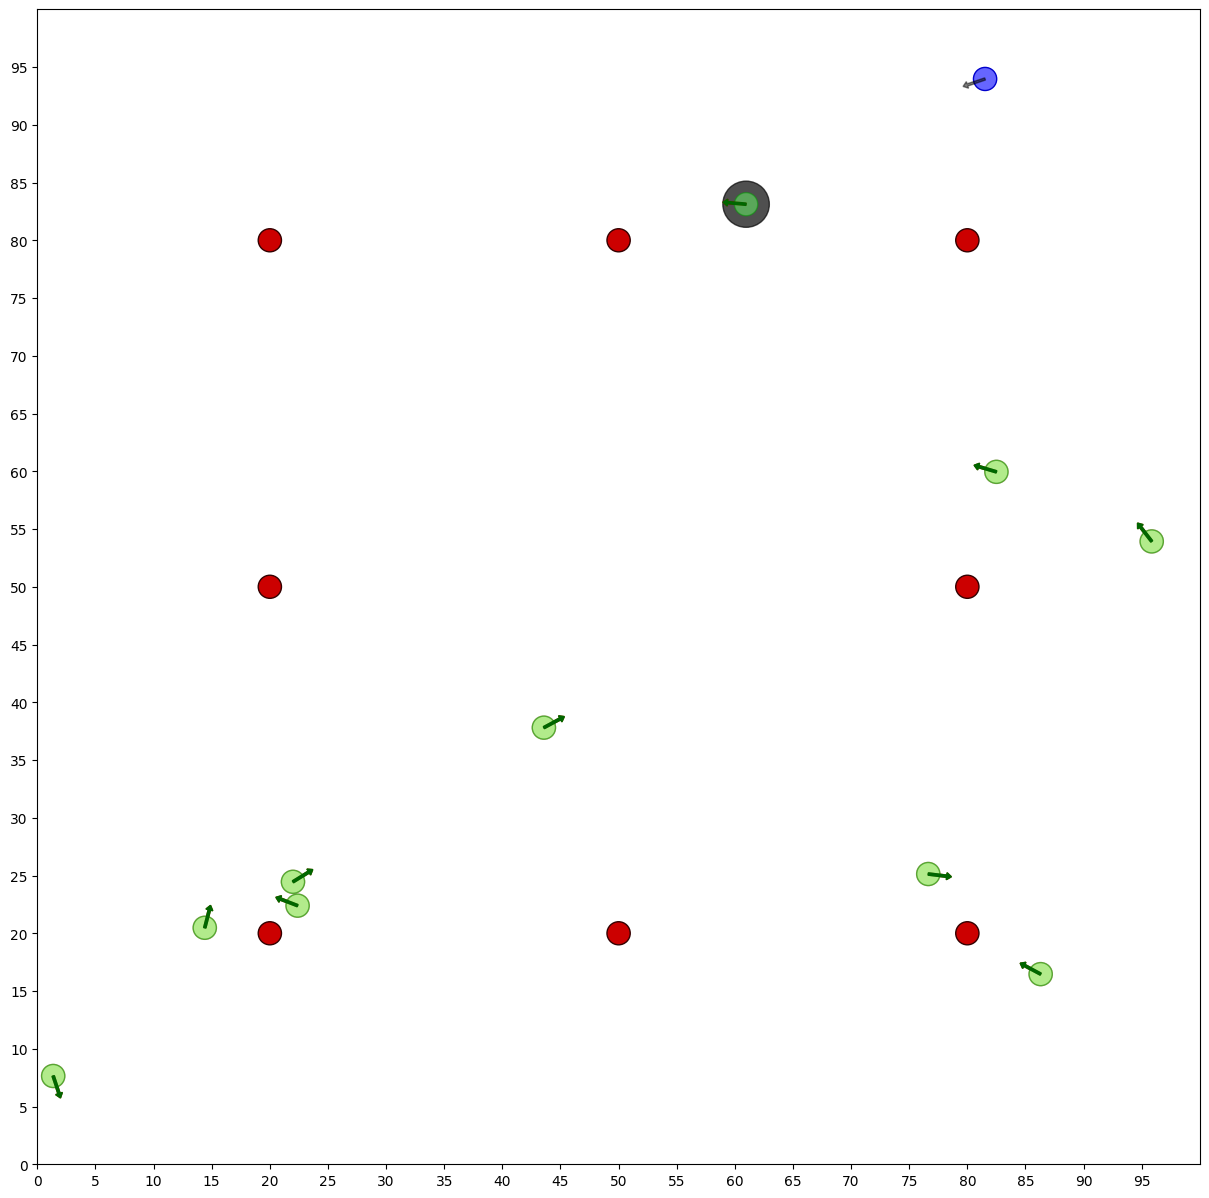

[2.17194796303972e-120, 7.870653851566397e-196, 2.915143736052066e-105, 4.841984992184139e-168, 7.916797200978204e-39, 1.7681691442591379e-37, 2.331530094508757e-172, 1.5858852941188676e-157, 4.22744005137332e-107, 7.251979527490963e-29]


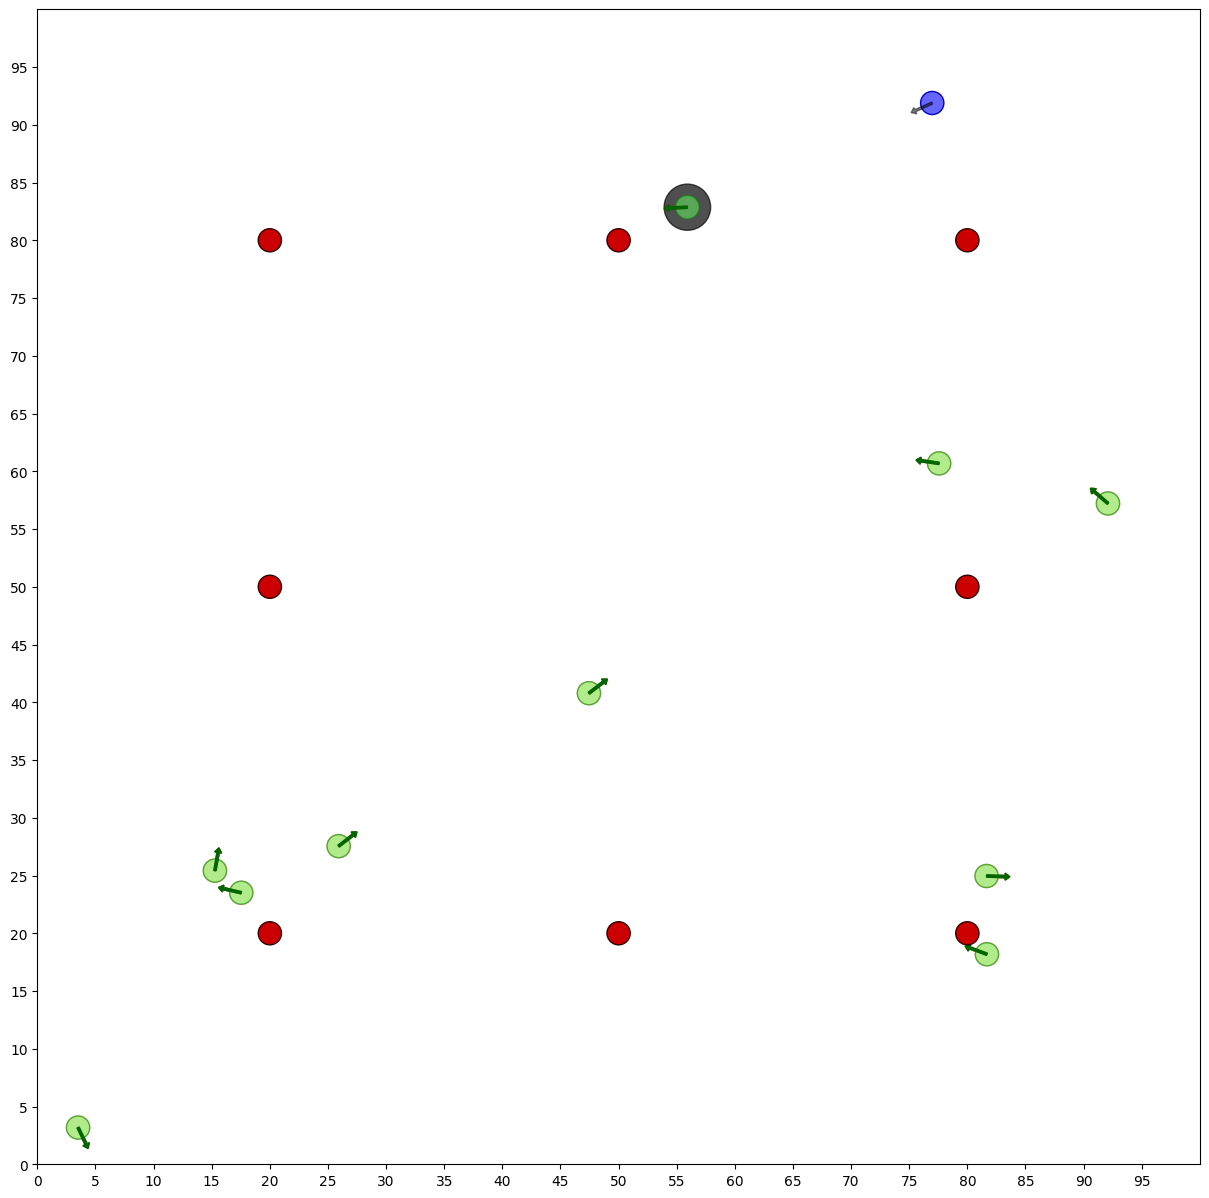

In [40]:
# Particle filter without resampling
def particleFilter():
    myrobot = robot() # blue
    myrobot = myrobot.move(0.1, 5.0)
    myrobot.set(50.0, 50.0, pi/2.0)

    Z = myrobot.sense()

    N = 100
    p = []
    moveTimes=20

    #here we create the particles with noise (Initialization phase)
    for i in range(N):
        x = robot()
        x.set_noise(0.05, 0.05, 5.0)
        p.append(x)

    for i in range(moveTimes):
        myrobot = myrobot.move(0.1, 5.0)
        Z = myrobot.sense()

        #move all the particles
        p2 = []
        for i in range(N):
            p2.append(p[i].move(0.1, 5.0))
        p = p2

        #compute for each particle the probability of being in that position
        w = []
        for j in p:
            w.append(j.measurement_prob(Z))
        print (w)

        max_value = max(w) #orange
        max_value_index = w.index(max_value)
        visualization(myrobot,i, p2, p, w)


    ##print ("max_value "+str(max_value_index))

particleFilter()

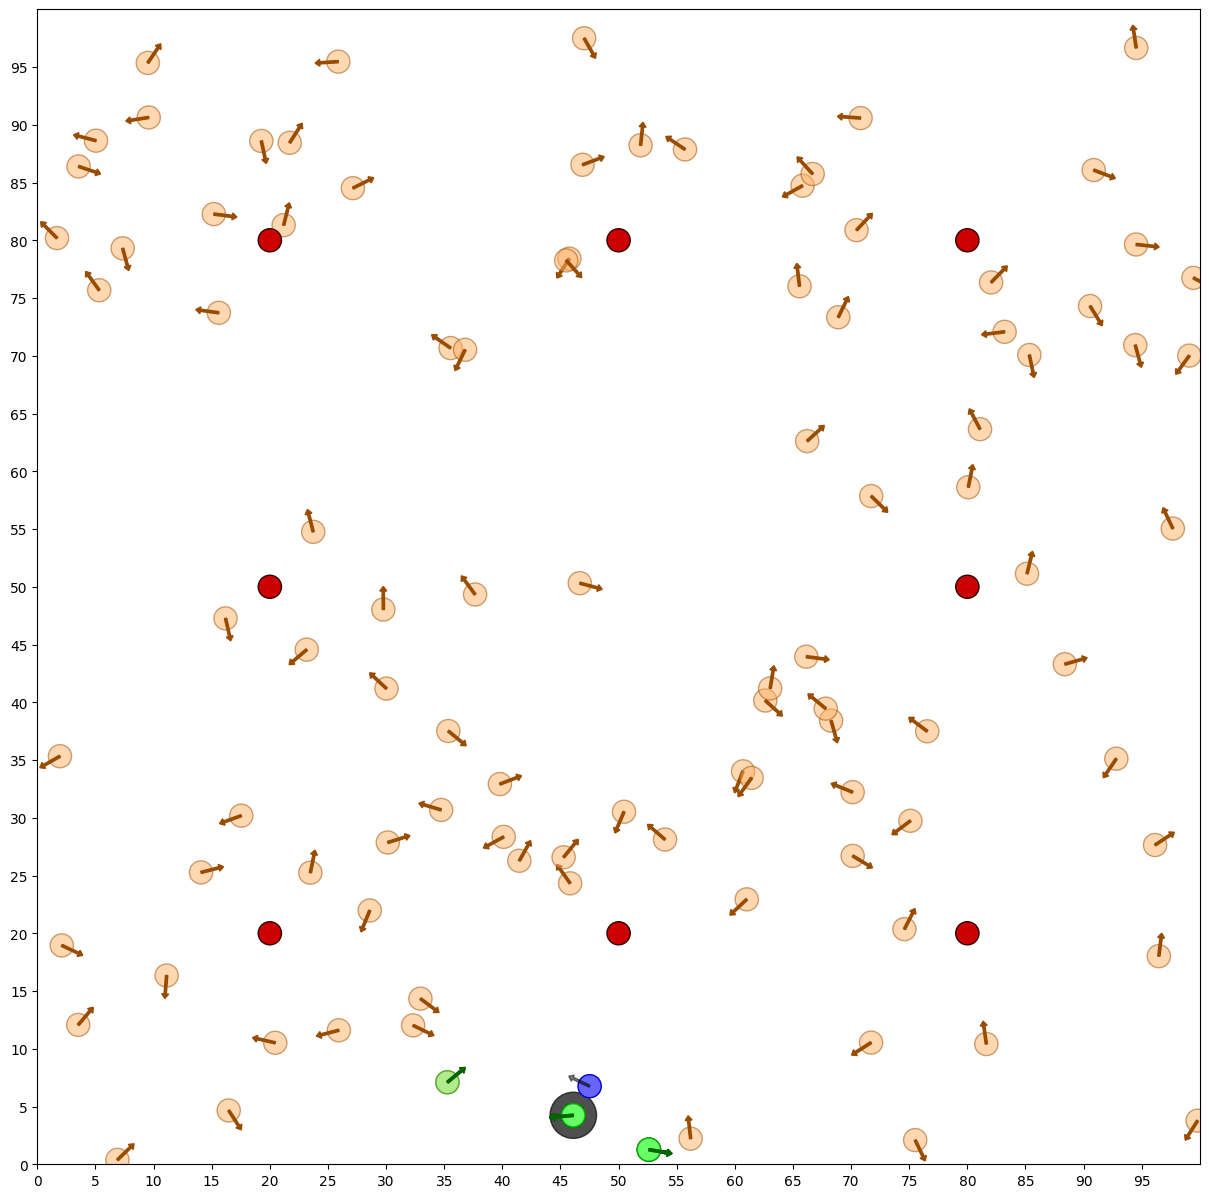

3.2547697927398893


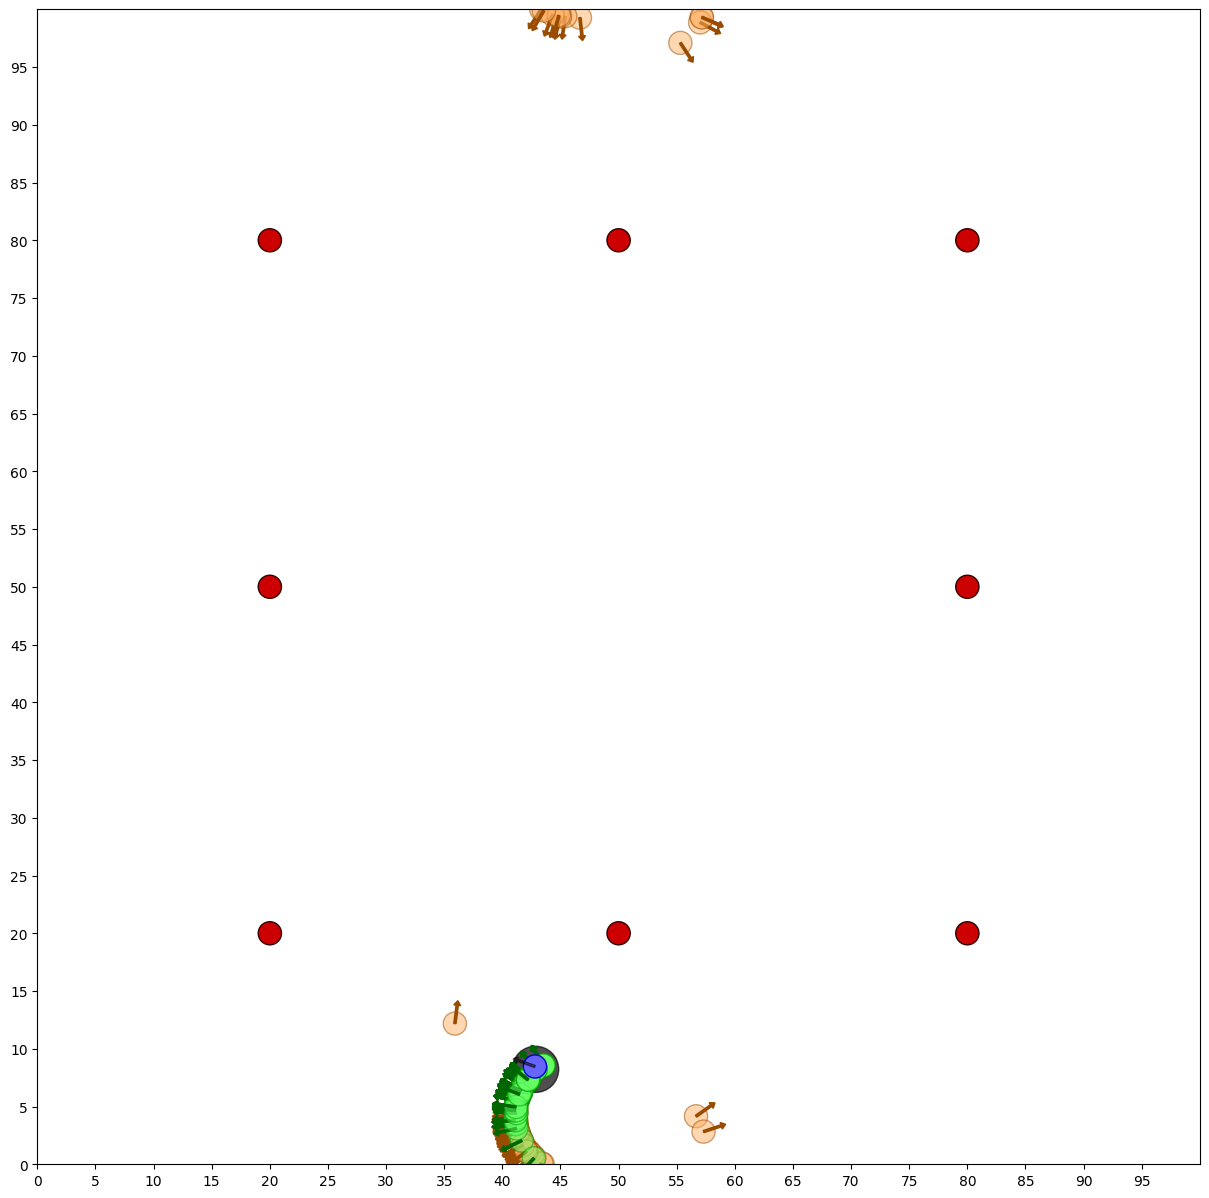

2.415459998466947


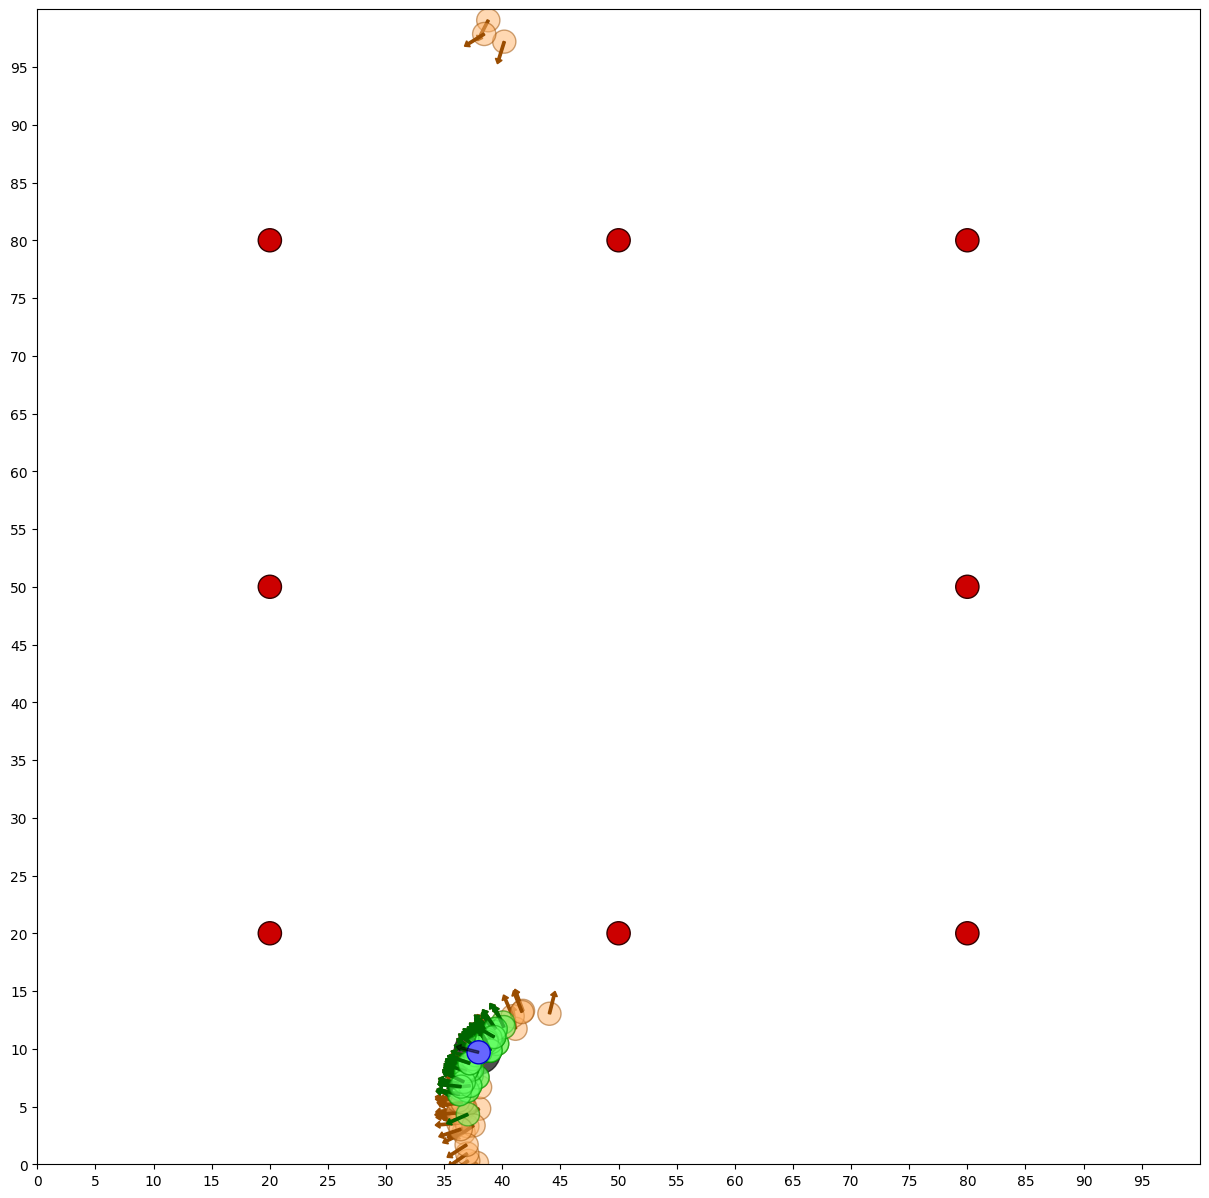

1.7373042152426477


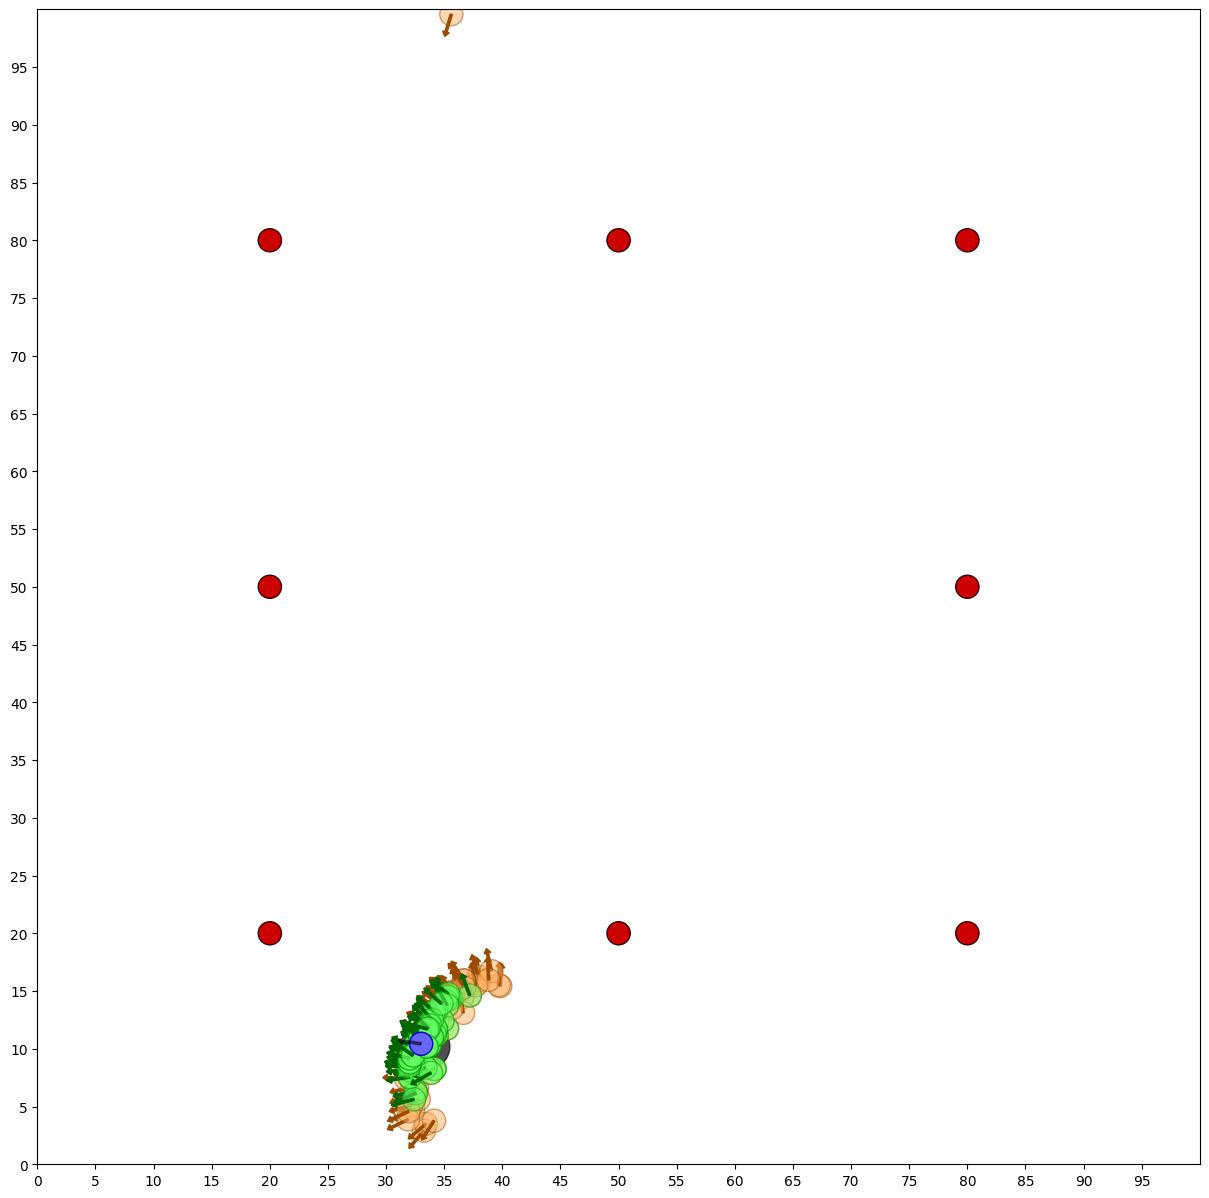

1.903022048235834


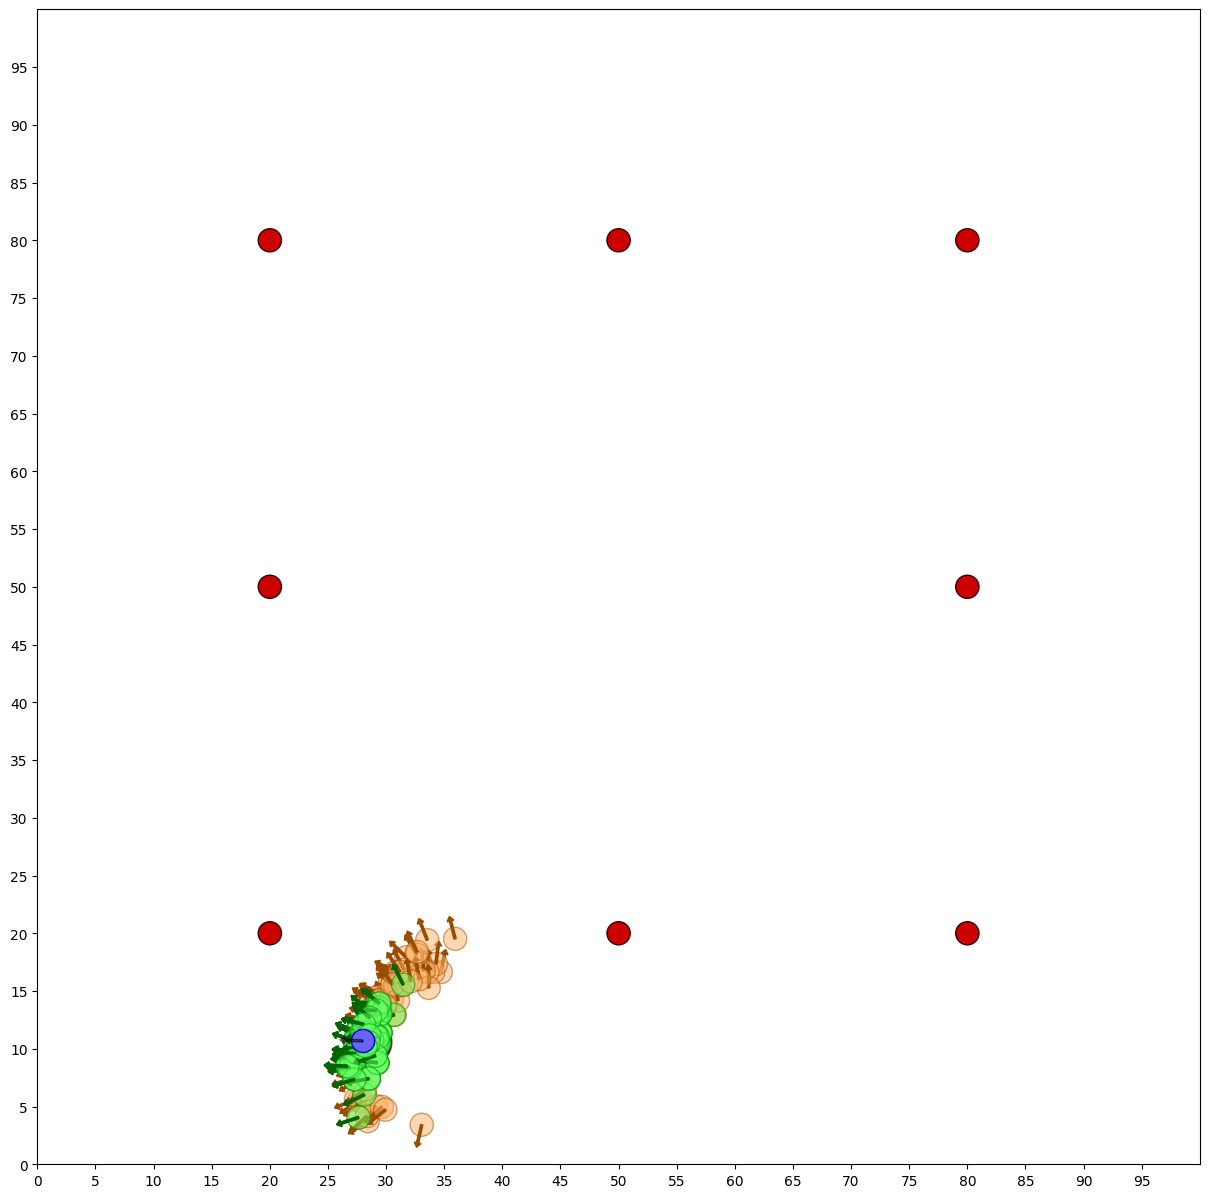

1.7492056117471597


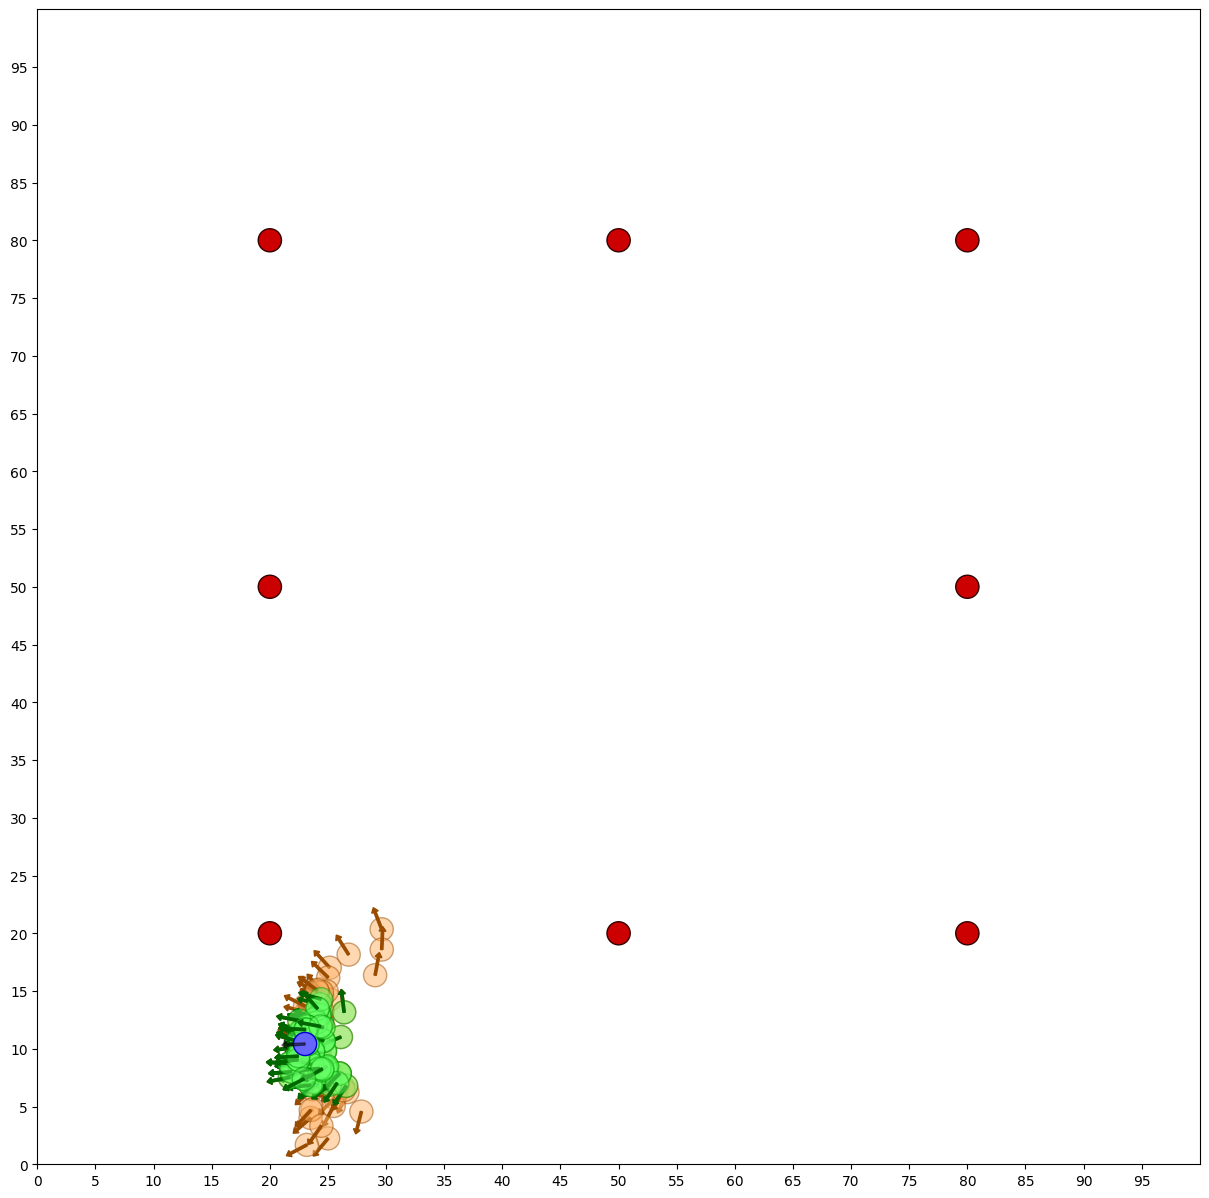

2.0499631428203724


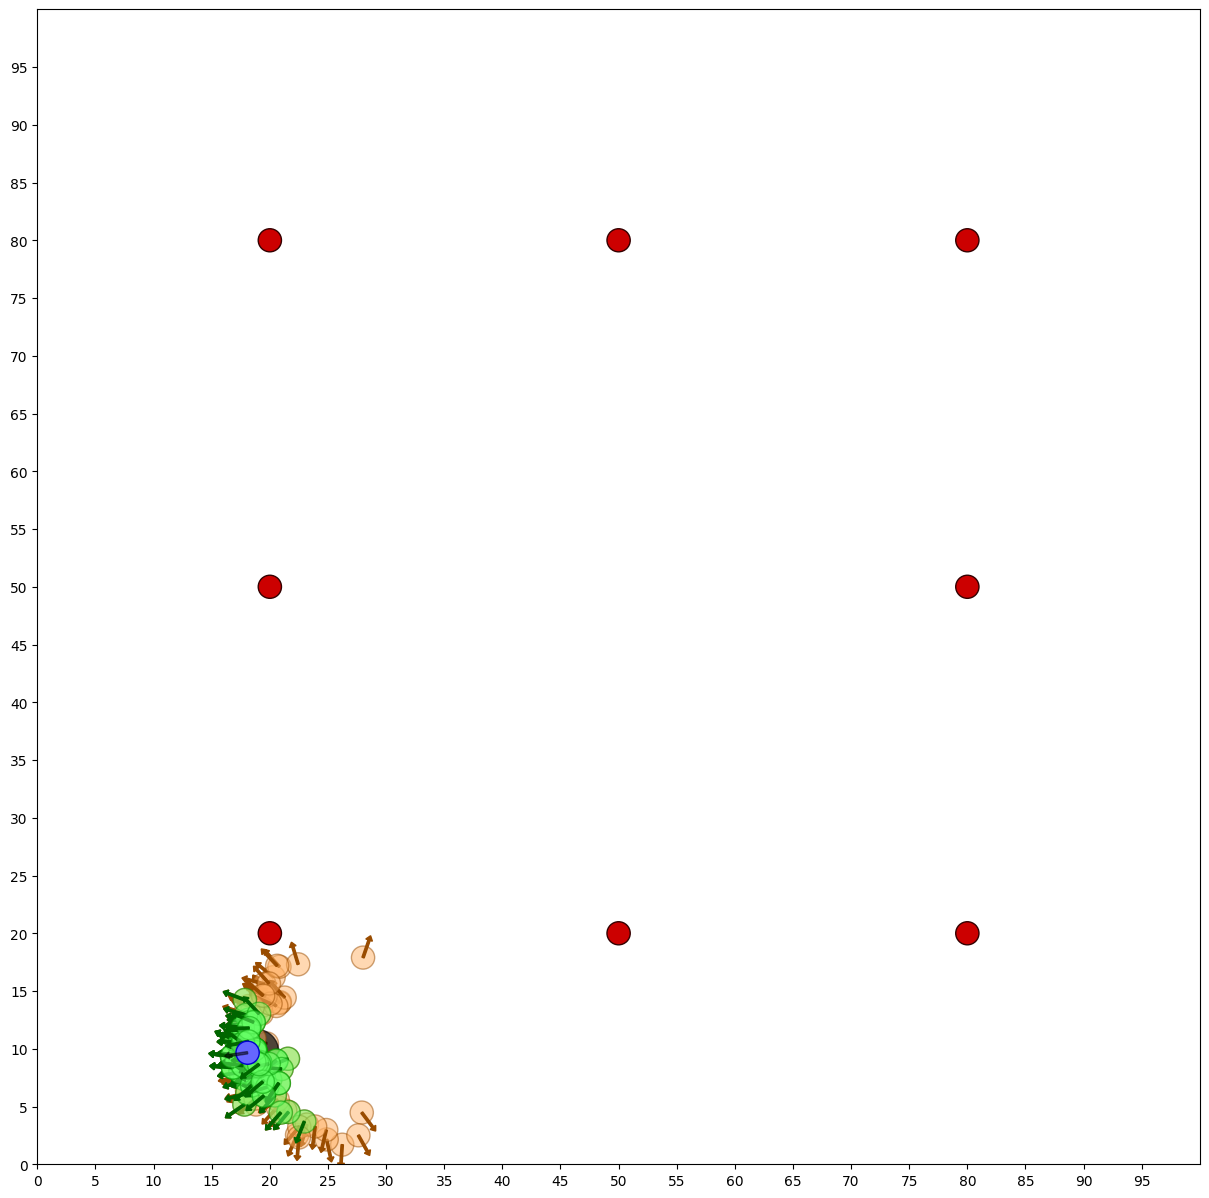

2.0770944187857294


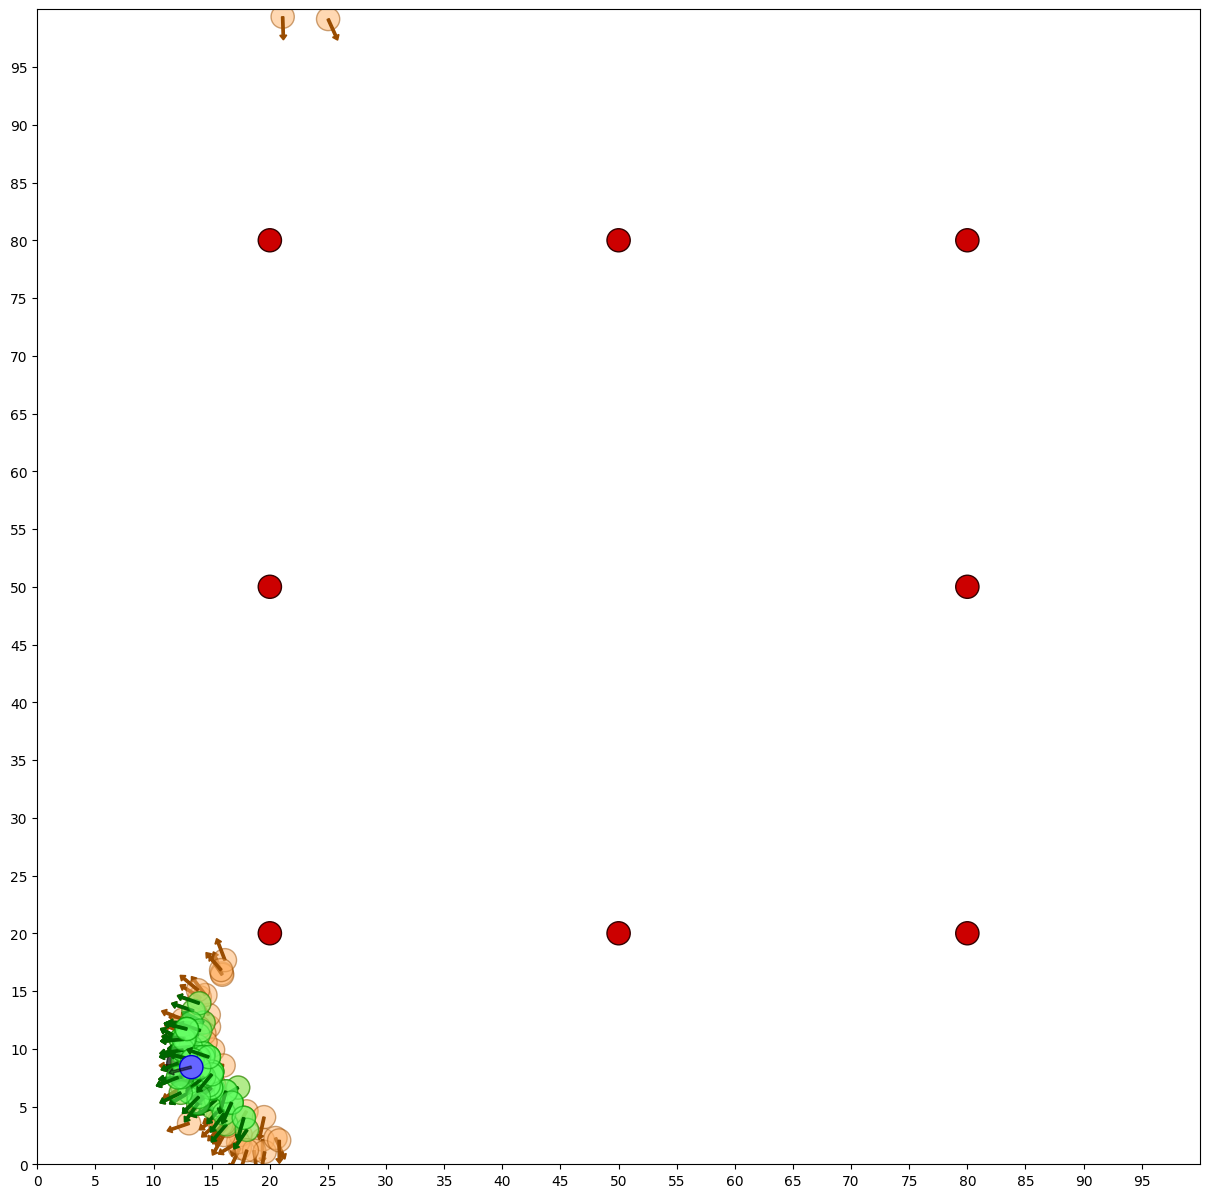

2.2907363169841966


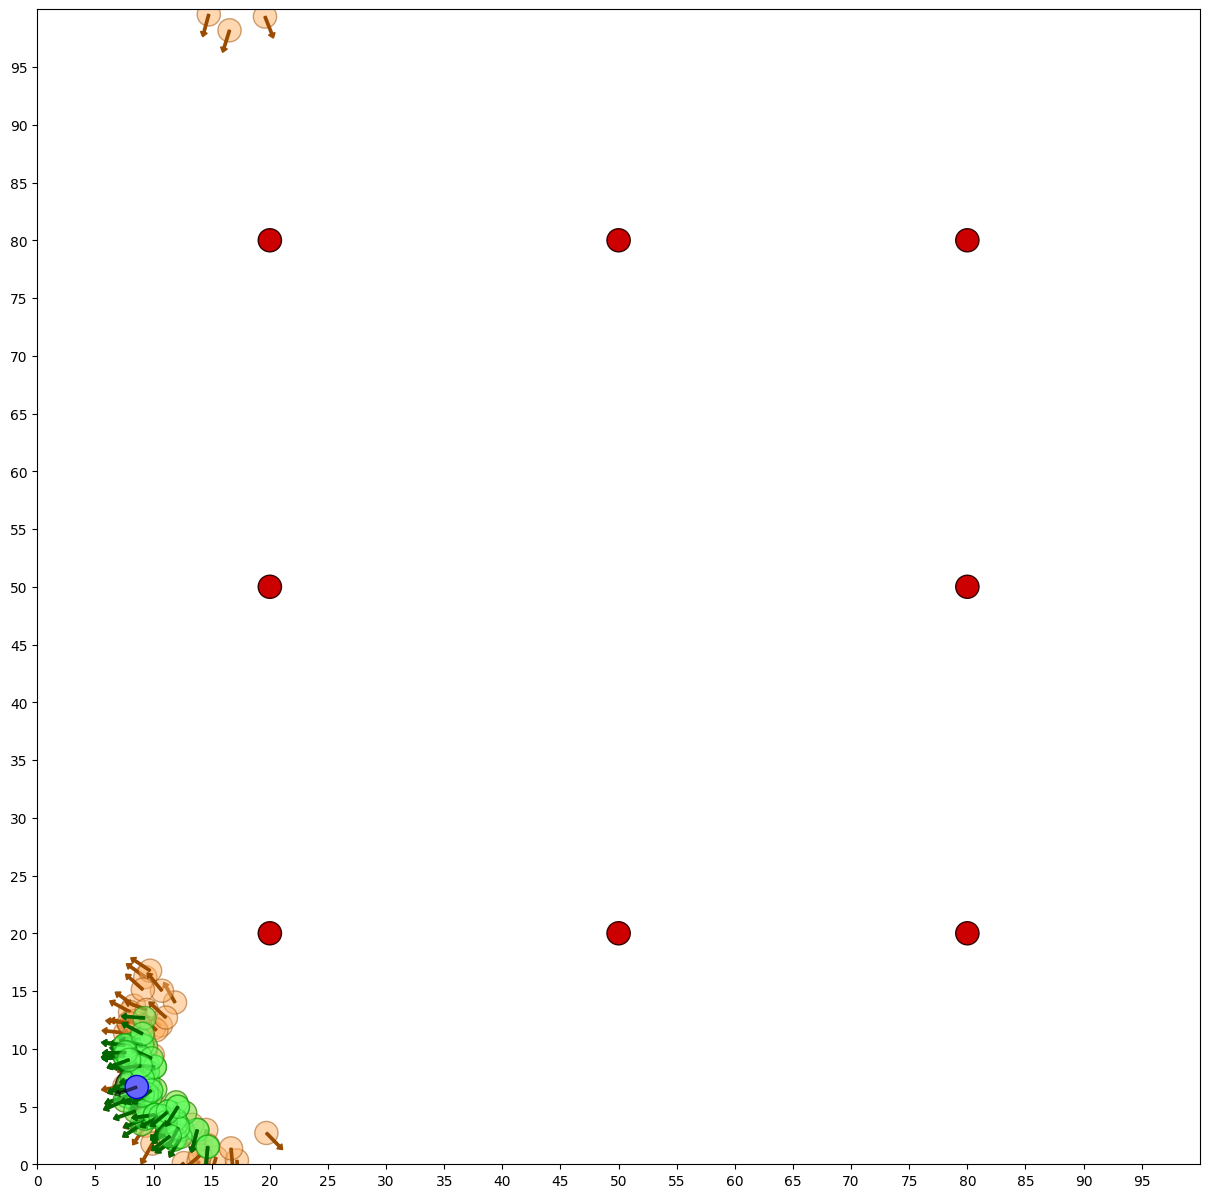

2.7870749160082875


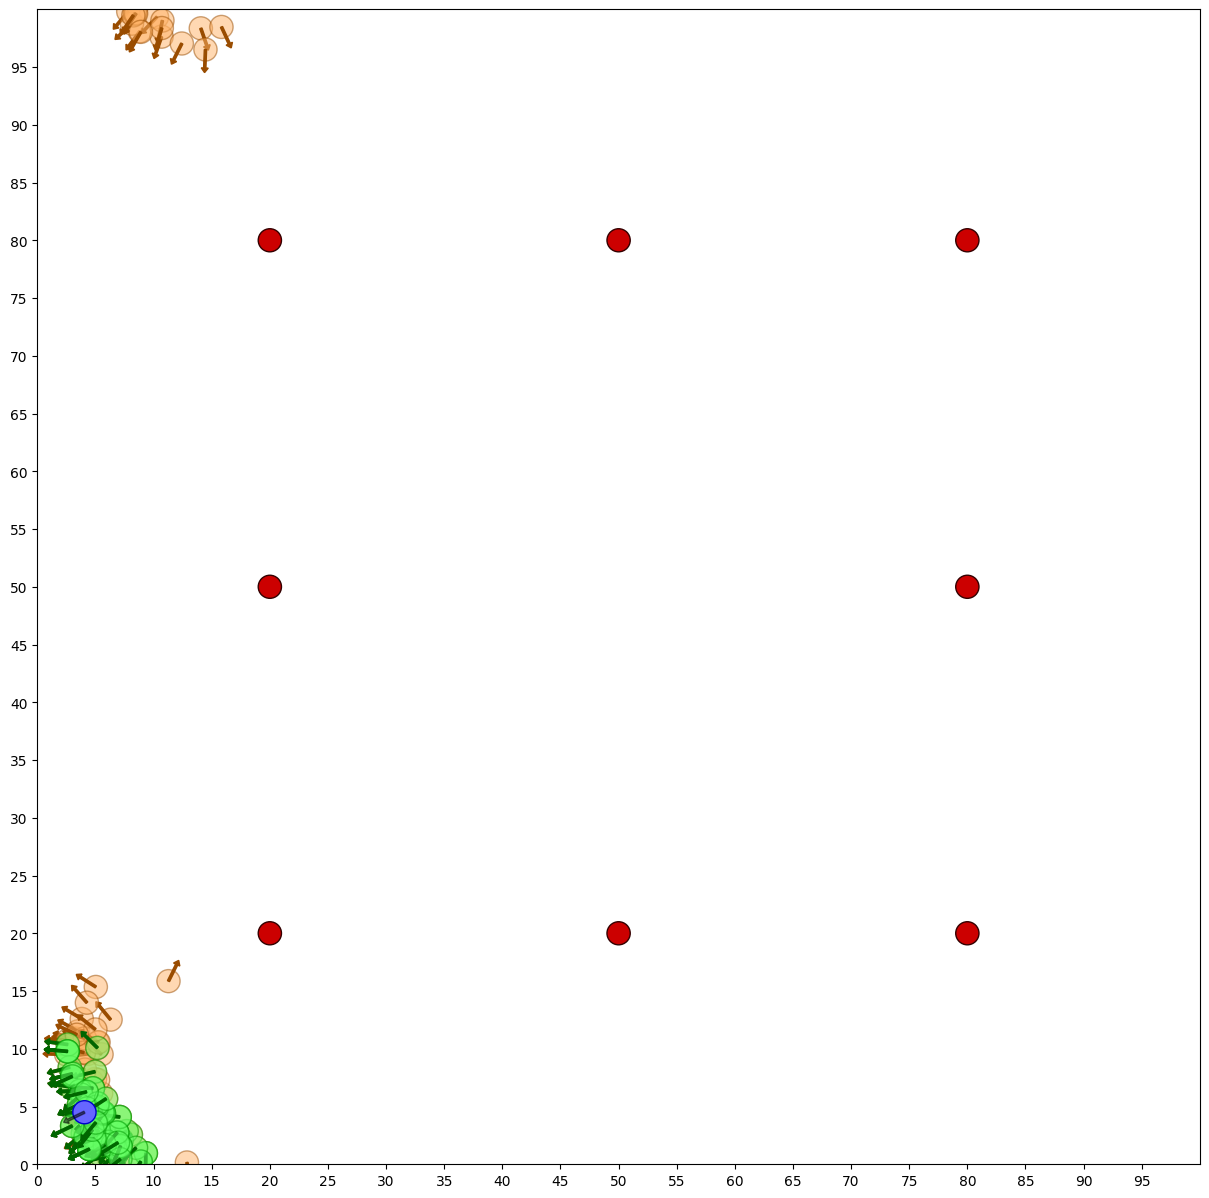

2.819564084300848


In [44]:
def fullParticleFilter(N = 100):
    myrobot = robot()
    moveTimes = 10
    p = []
    for i in range(N):
        x = robot()
        x.set_noise(0.05, 0.5, 5.0)
        p.append(x)

    for t in range(moveTimes):

        myrobot = myrobot.move(0.1, 5.0)
        Z = myrobot.sense()

        p2 = []
        for i in range(N):
              p2.append(p[i].move(0.1, 5.0))
        p = p2

        #print (eval(myrobot,p))

        w = []
        for i in range(N):
            w.append(p[i].measurement_prob(Z))

        p3 = []
        #Resampling wheel
        index = int(random.random() * N)
        beta = 0.0
        mw = max(w)
        for i in range(N):
            beta += random.random() * 2.0 * mw
            while beta > w[index]:
                beta -= w[index]
                index = (index + 1) % N
            p3.append(p[index])
        p=p3
        '''
        :param robot:   the current robot object
        :param step:    the current step
        :param p:       list with particles
        :param pr:      list of resampled particles
        :param weights: particle weights
        '''
        visualization(myrobot,t, p2, p, w)
        print(eval(myrobot,p))

# Resampled particles in green
# Particles in yellow
# Ground truth (robot's position) in blue
fullParticleFilter()

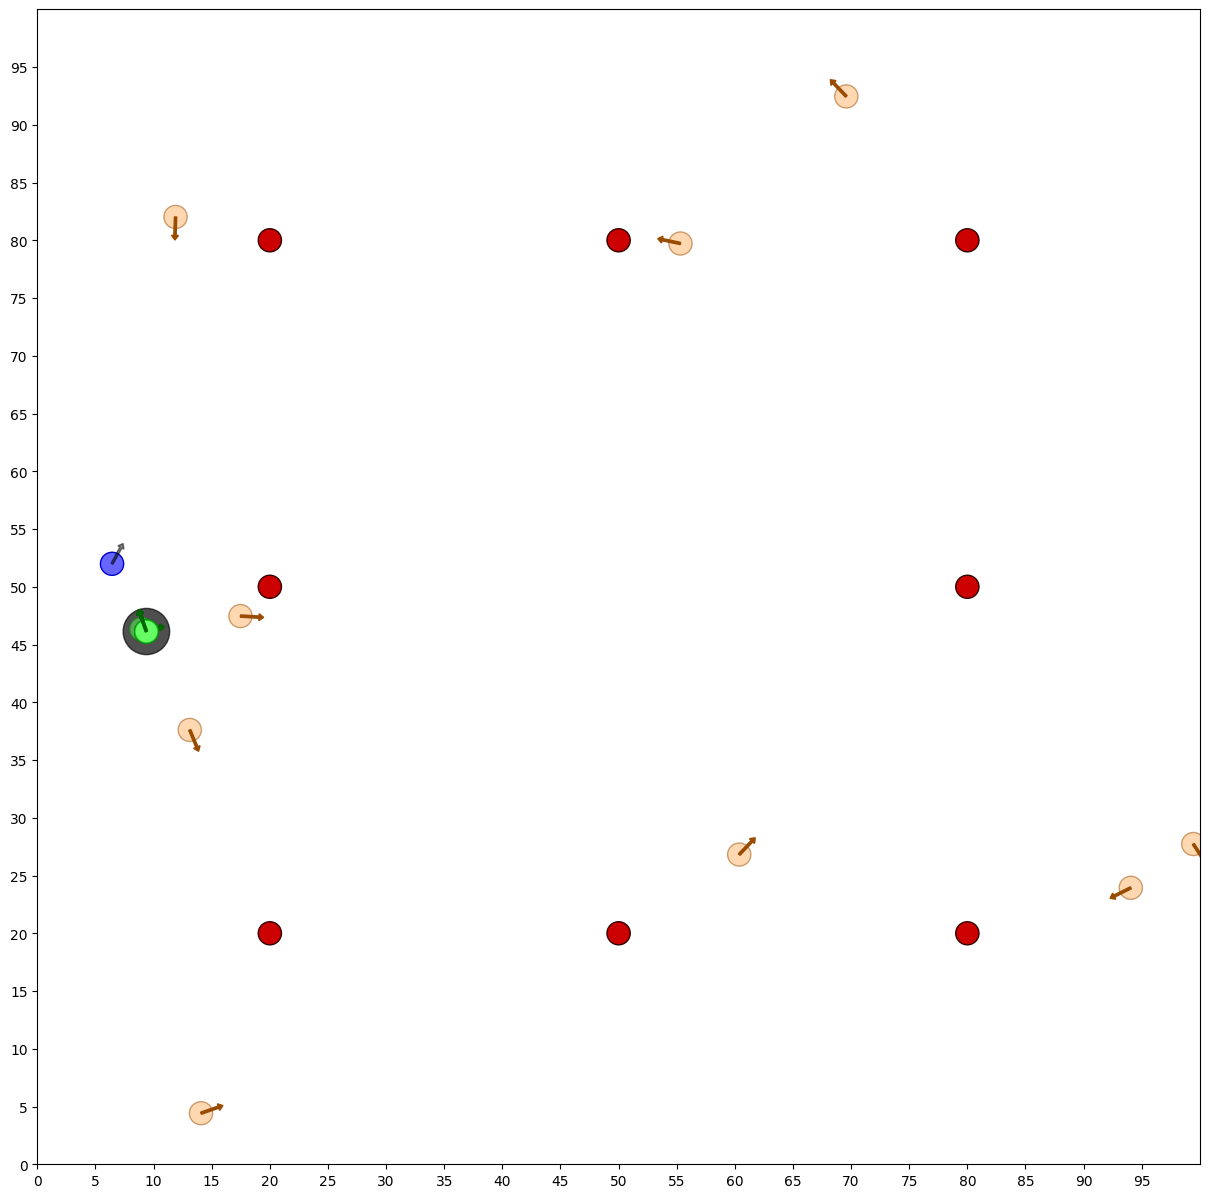

6.527028576411955


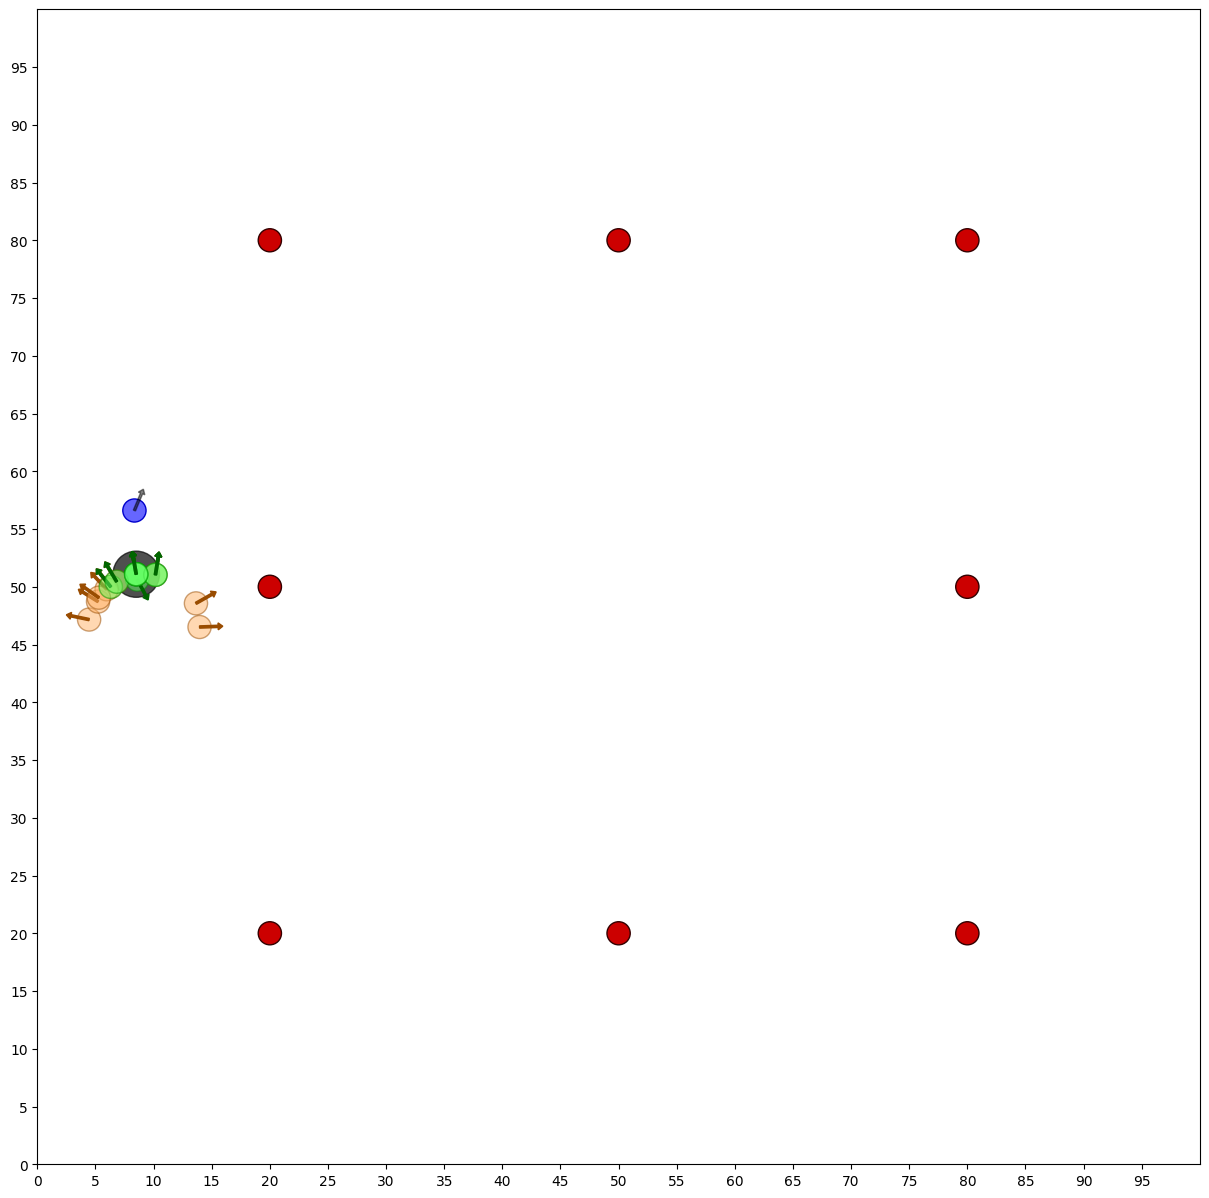

5.855846407712294


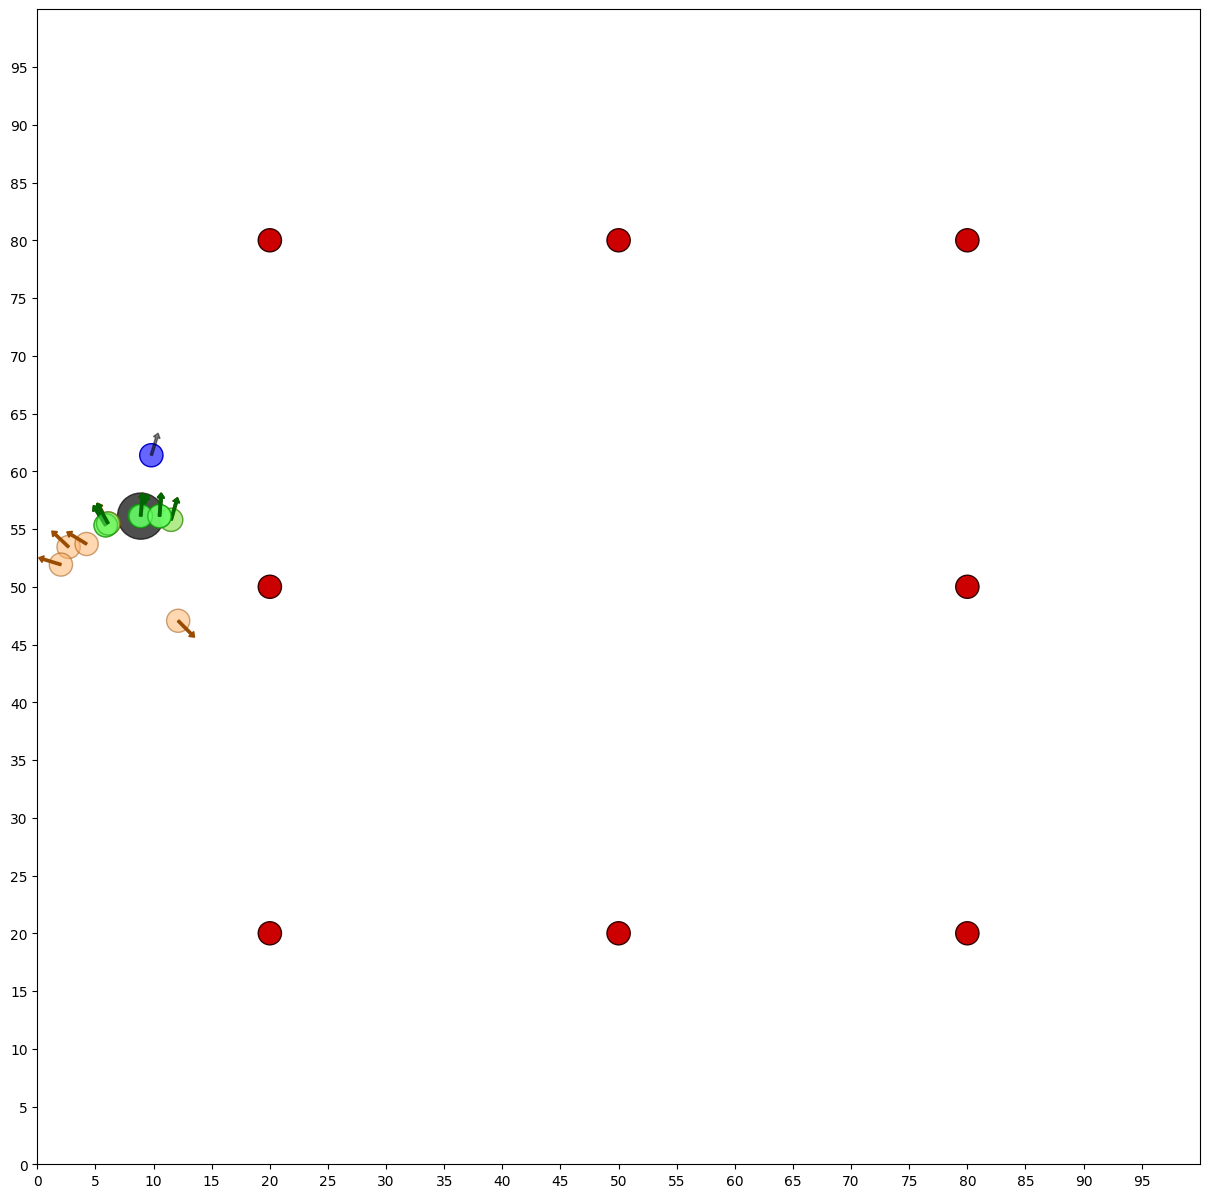

5.926892214139331


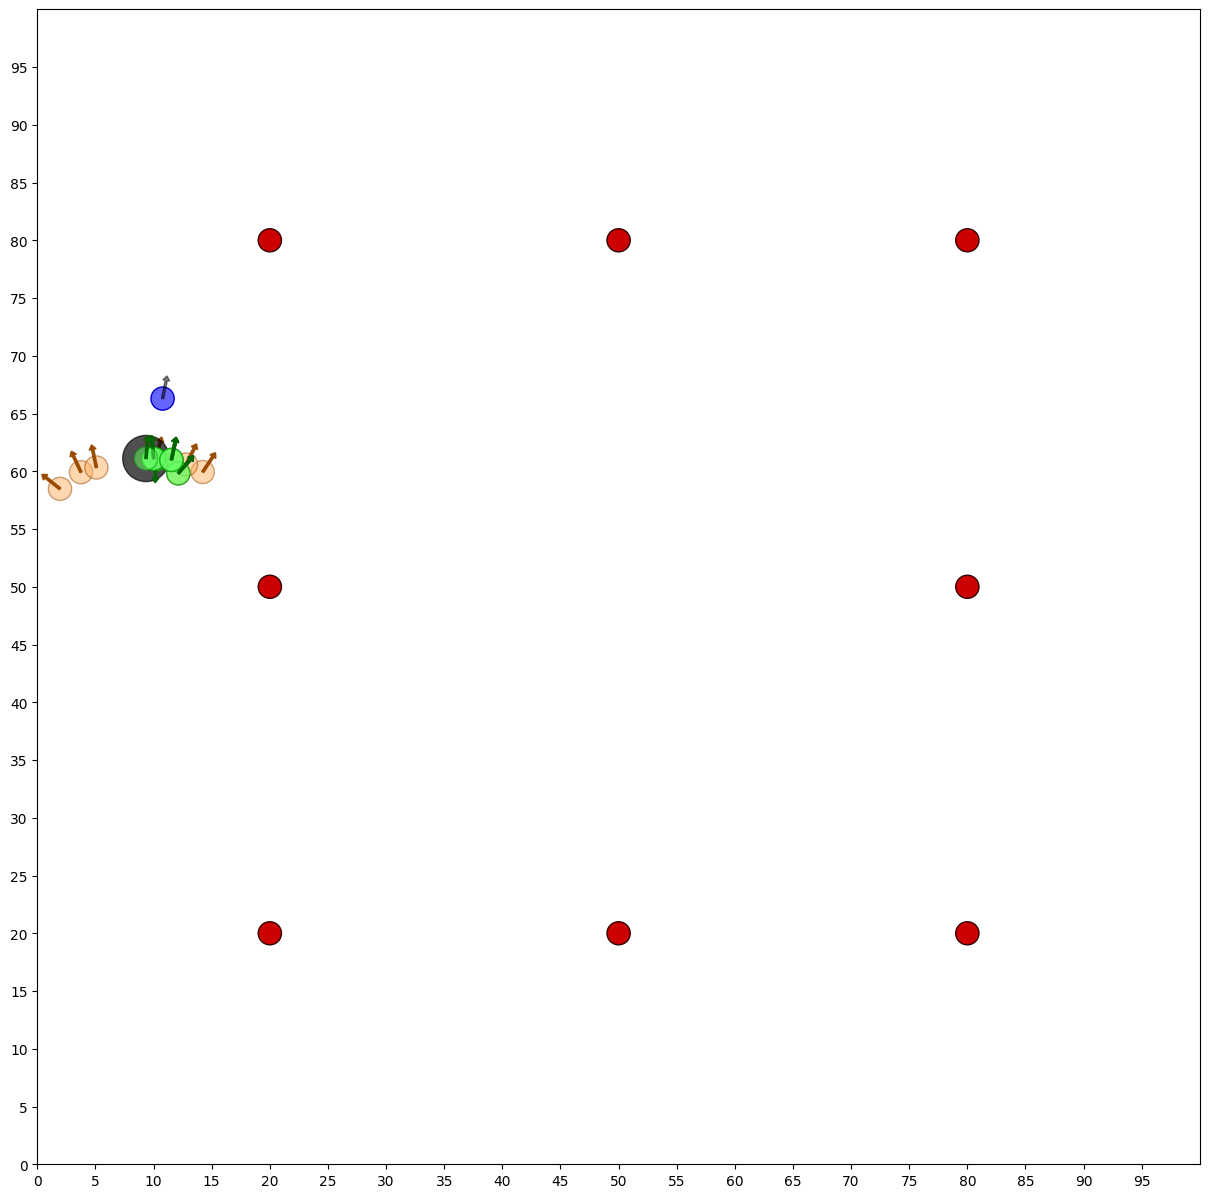

5.578947445522752


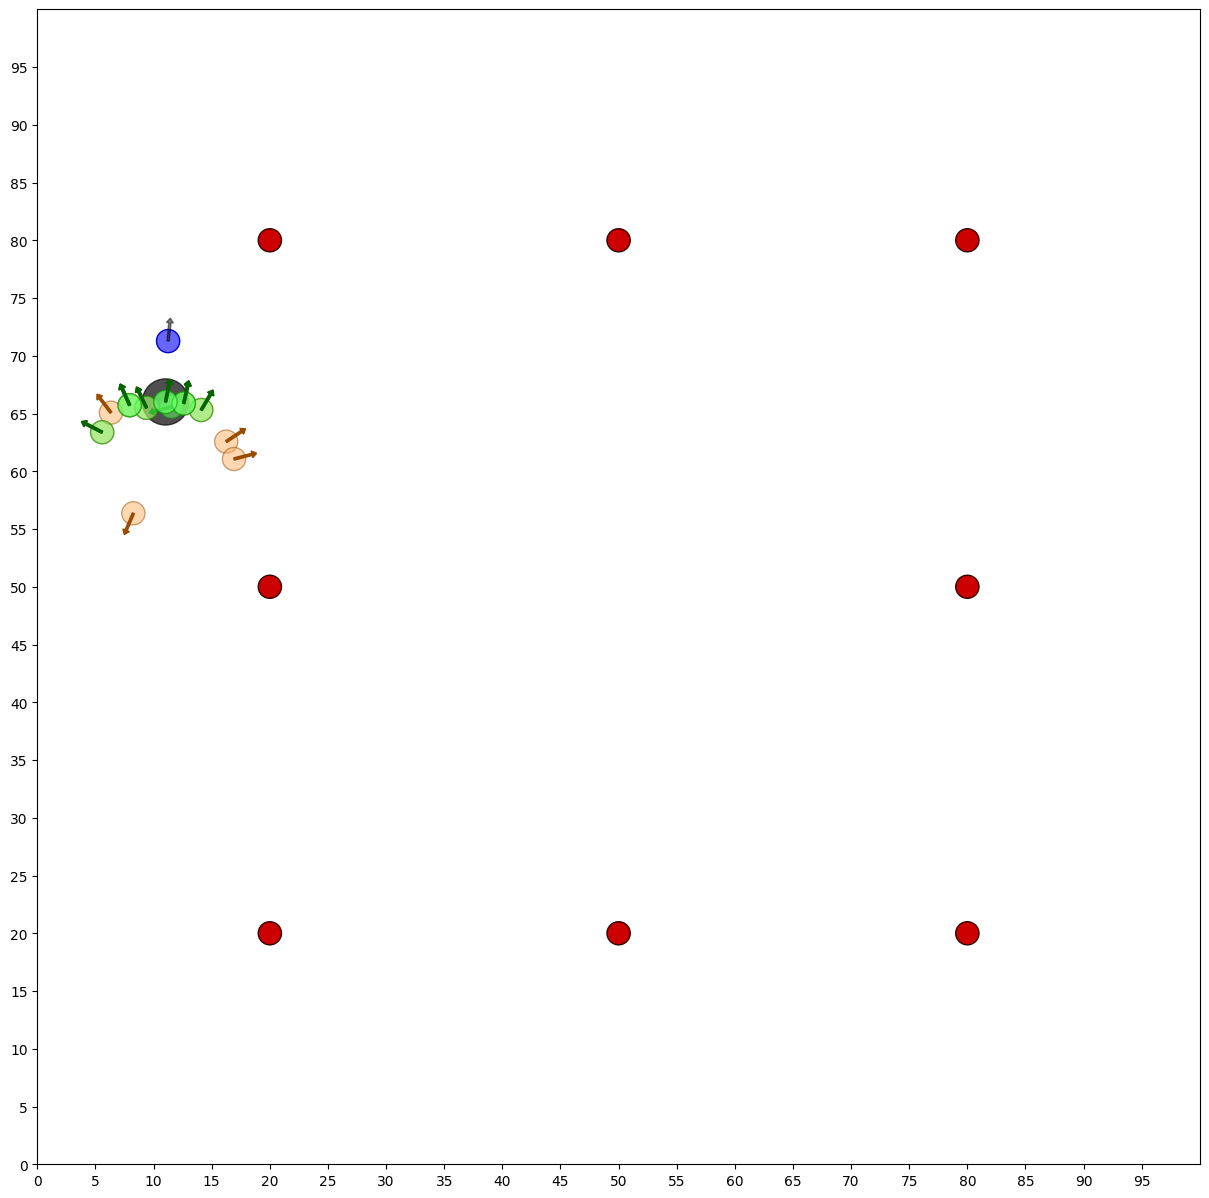

6.267444998855075


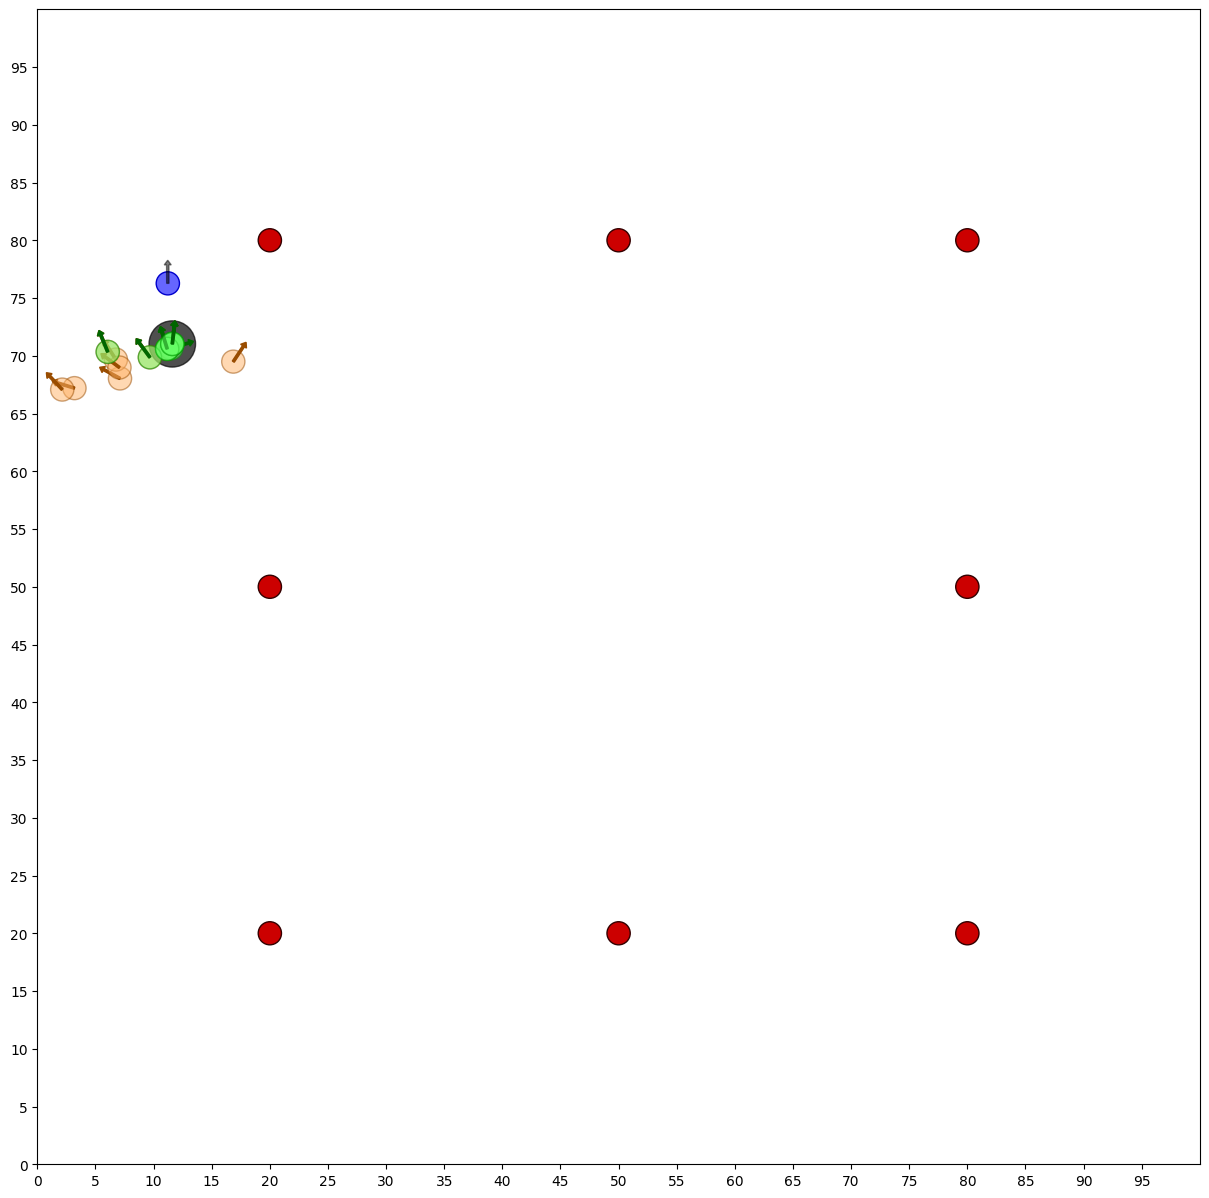

5.814288148892301


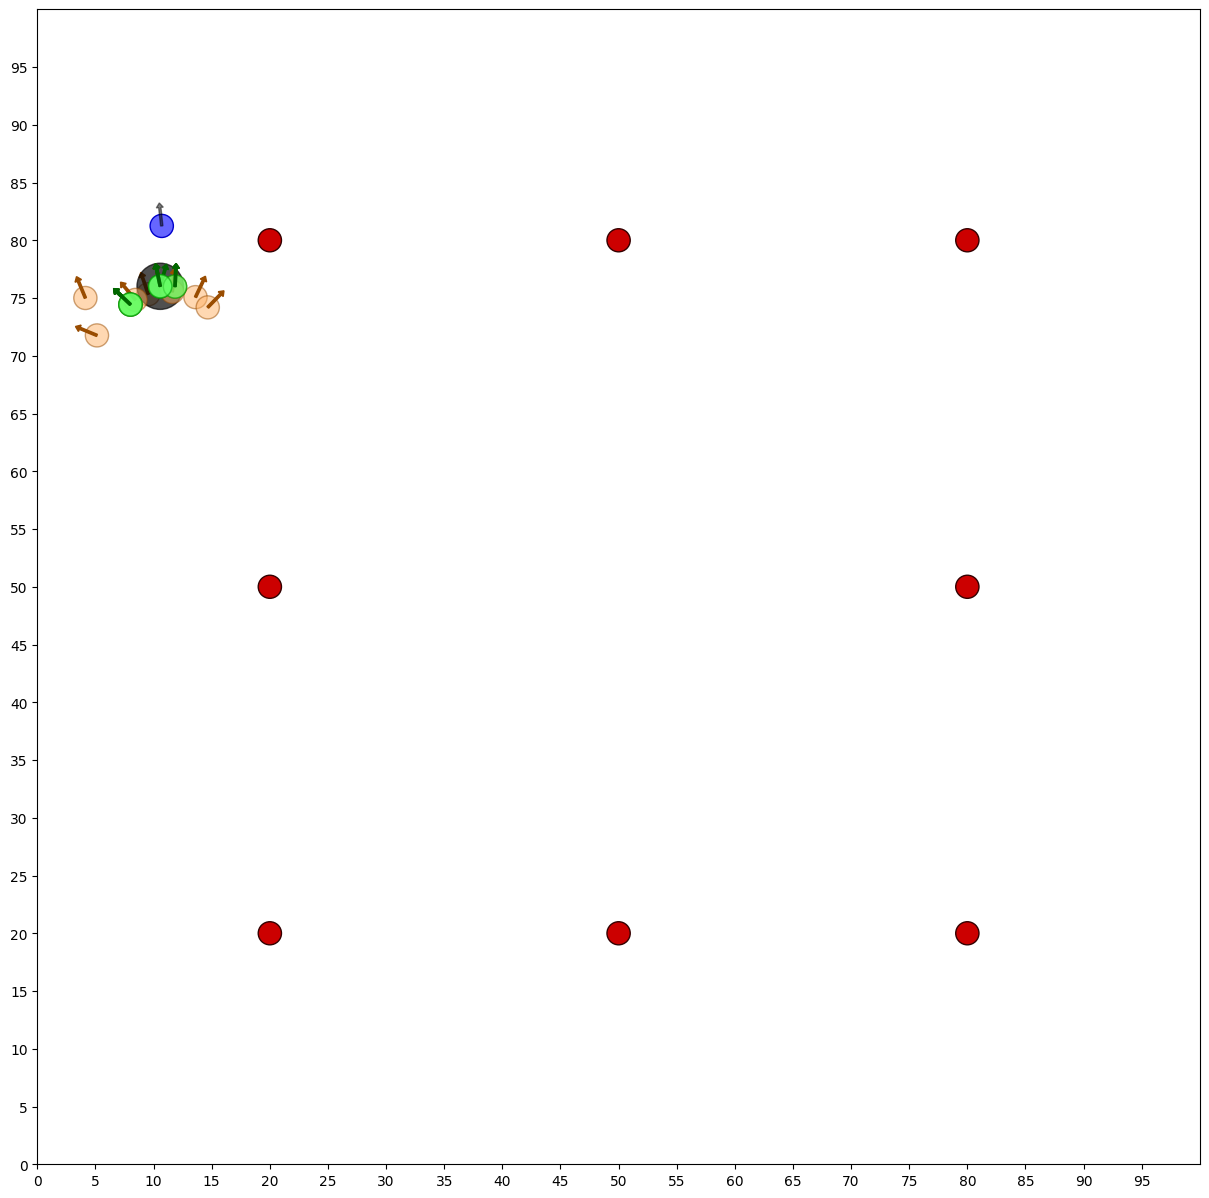

6.09568227208719


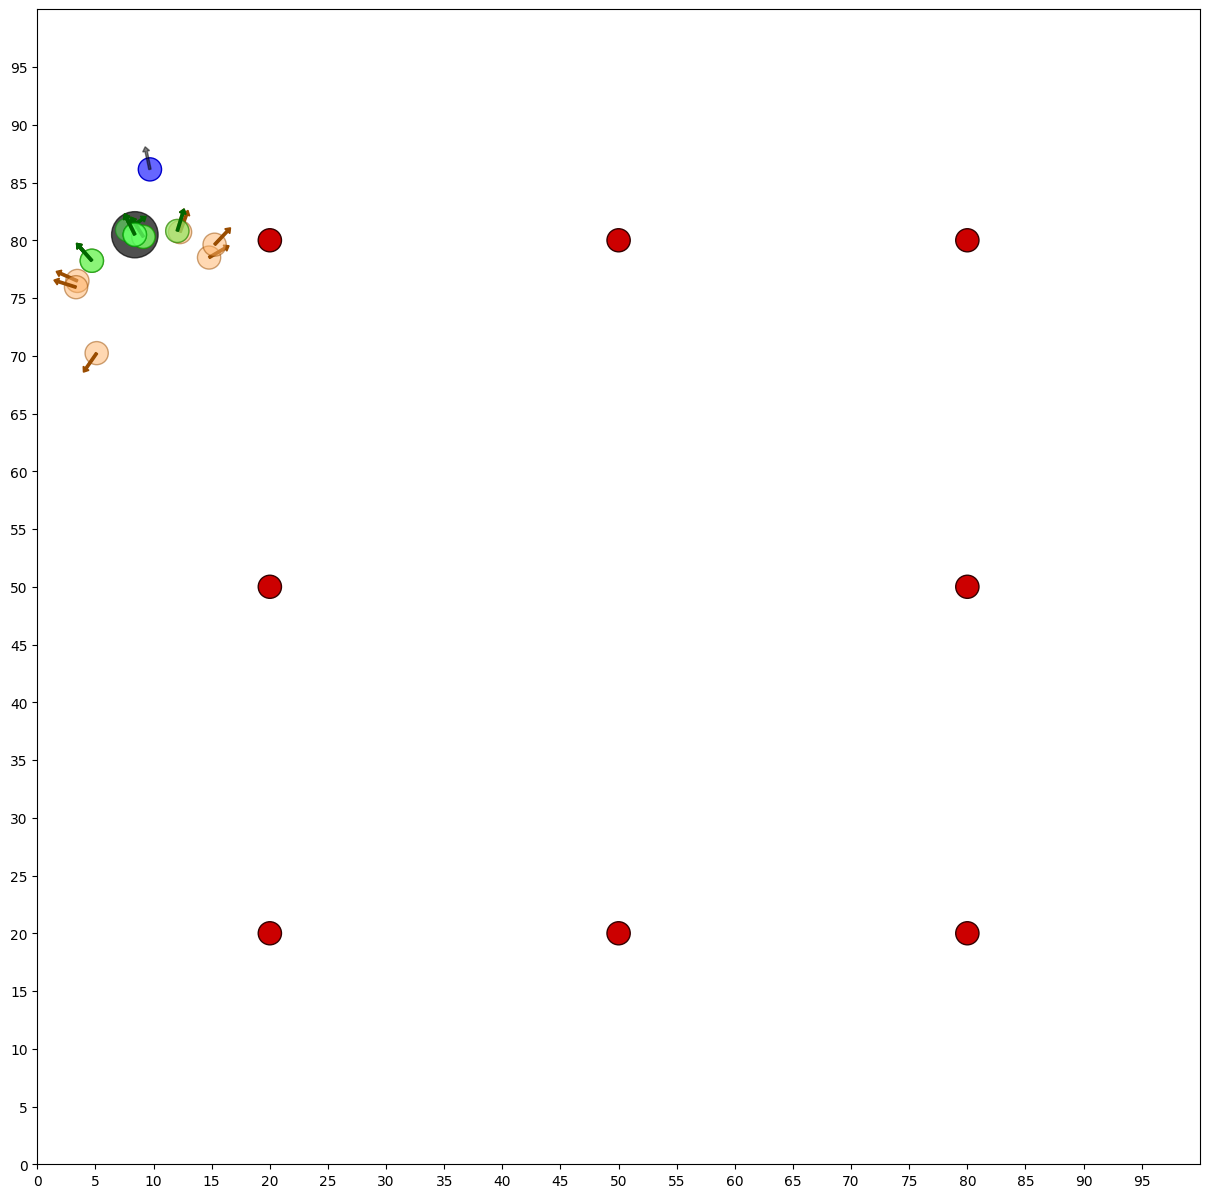

6.508533852949239


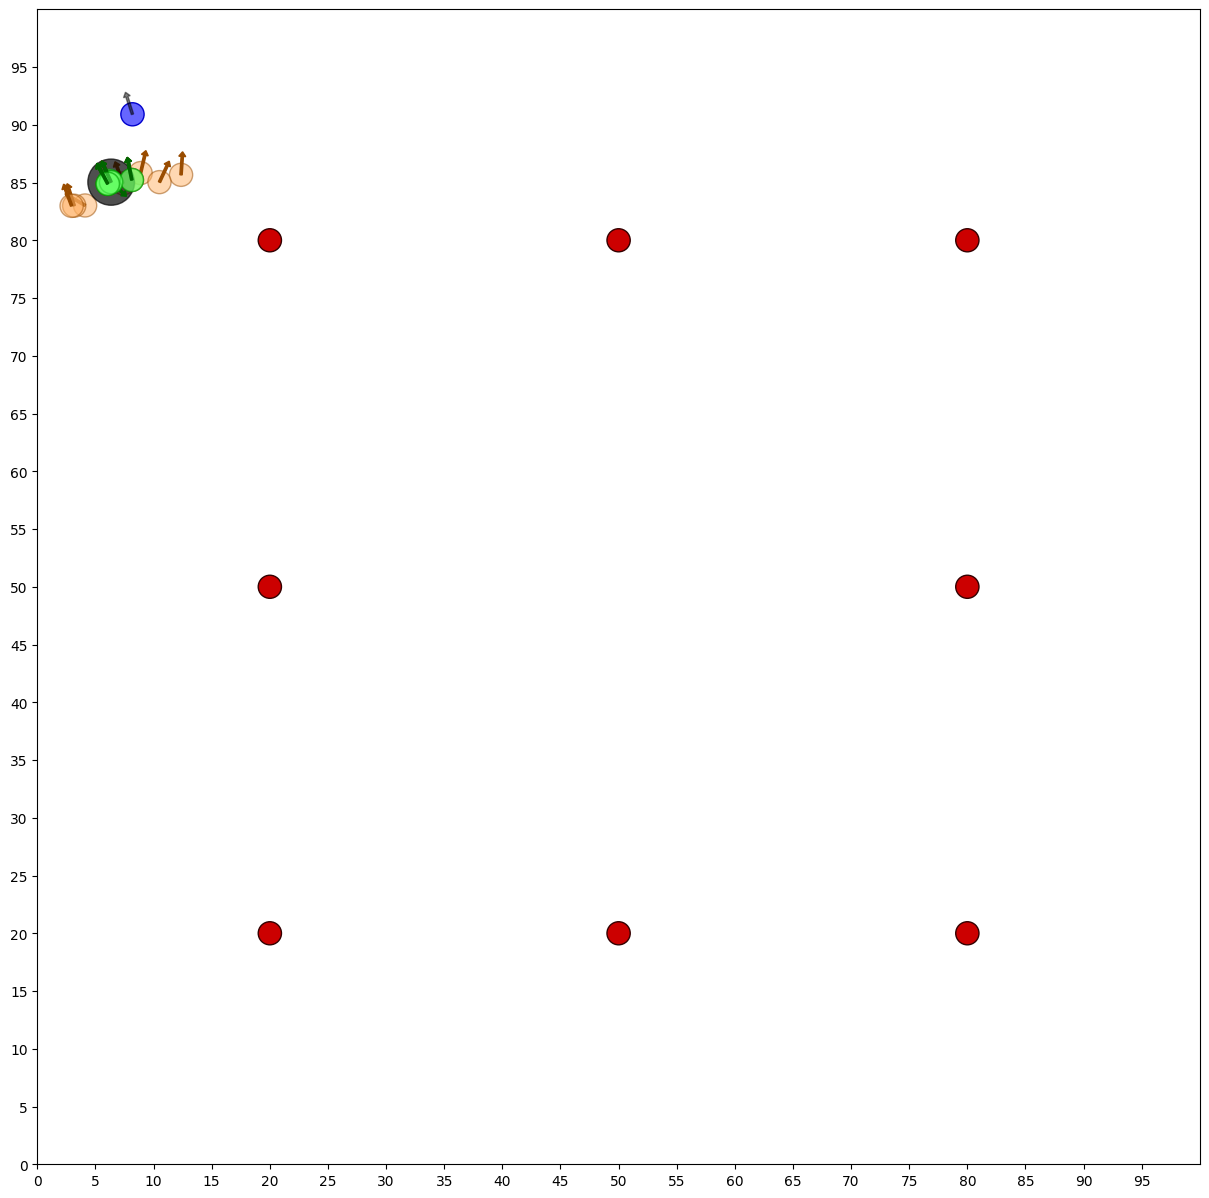

6.146387983750915


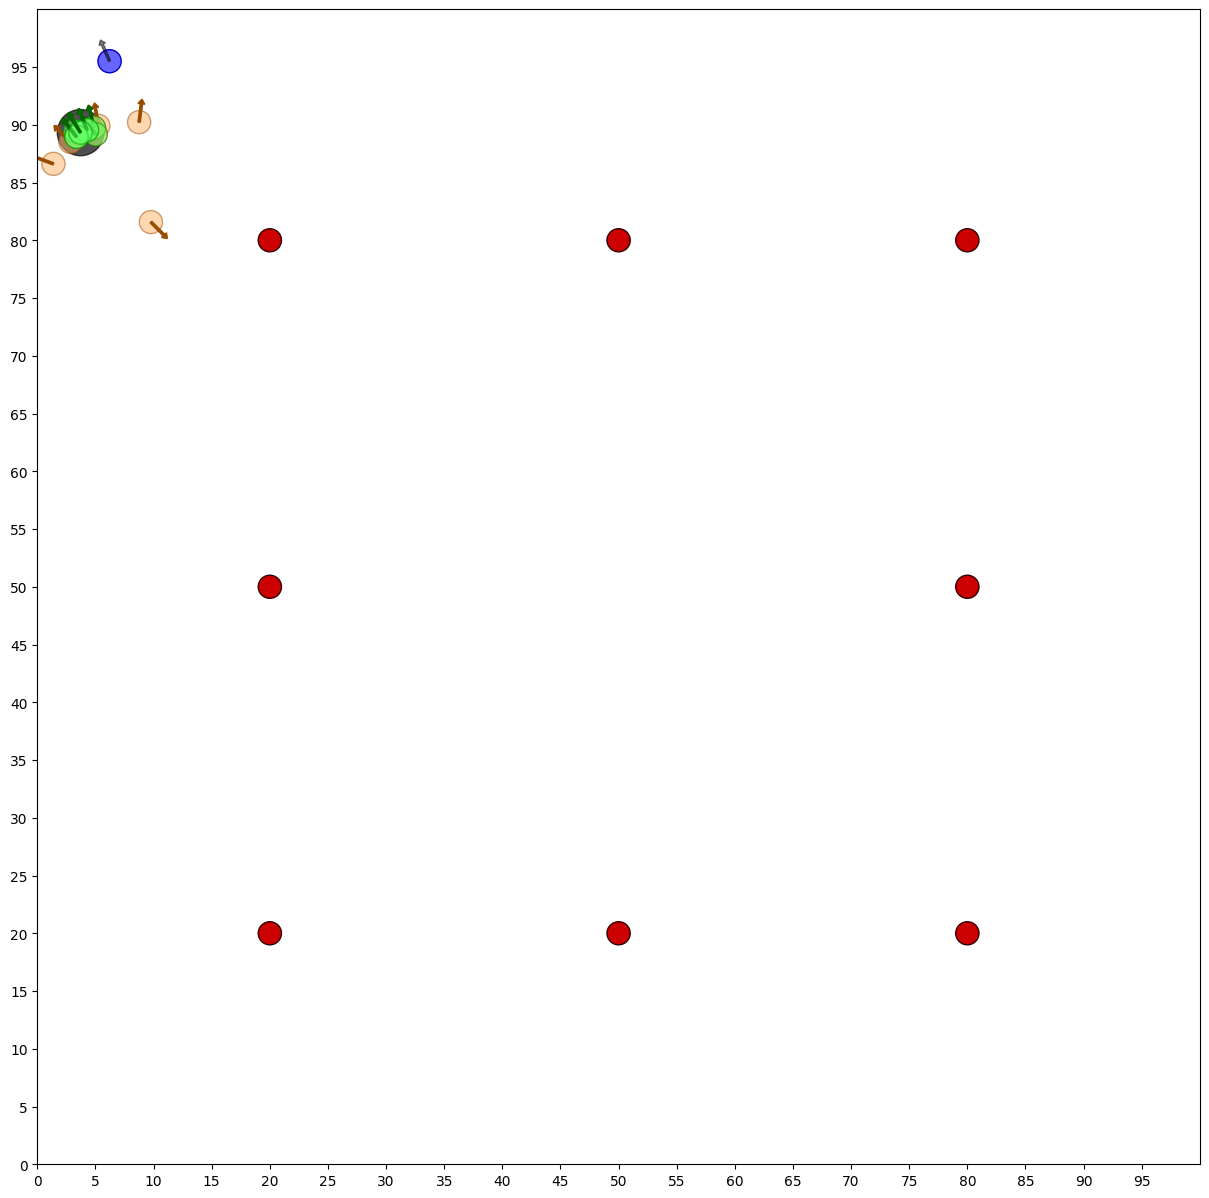

6.593210895230236


In [52]:
landmarks2 = [[20.0, 20.0], [20.0, 80.0], [20.0, 50.0],
             [50.0, 20.0], [50.0, 80.0], [80.0, 80.0],
             [80.0, 20.0], [80.0, 50.0], [50.0, 50.0],
             [35.0, 65.0], [70.0,65.0], [35.0,35.0], [70.0,35.0]]

landmarks = [[20.0, 20.0], [20.0, 80.0], [20.0, 50.0],
             [50.0, 20.0], [50.0, 80.0], [80.0, 80.0],
             [80.0, 20.0], [80.0, 50.0]]
def fullParticleFilterImprovedResampling(N = 50):
    myrobot = robot()
    moveTimes = 10
    p = []
    for i in range(N):
        x = robot()
        x.set_noise(0.05, 0.5, 5.0)
        p.append(x)

    for t in range(moveTimes):

        myrobot = myrobot.move(0.1, 5.0)
        Z = myrobot.sense()

        p2 = []
        for i in range(N):
              p2.append(p[i].move(0.1, 5.0))
        p = p2

        #print (eval(myrobot,p))

        w = []
        for i in range(N):
            w.append(p[i].measurement_prob(Z))

        p3 = []
        #Resampling wheel
        index = int(random.random() * N)
        beta = 0.0
        mw = max(w)
        for i in range(N):
            beta += random.random() * 2.0 * mw
            while beta > w[index]:
                beta -= w[index]
                index = (index + 1) % N
            p3.append(p[index])

        # Aggiungi particelle rigenerate casualmente intorno alle migliori
        num_random_particles = int(0.1 * N)  # rigenera il 10% delle particelle
        best_particles = sorted(p3, key=lambda particle: particle.measurement_prob(Z), reverse=True)[:num_random_particles]

        for i in range(num_random_particles):
            # Seleziona una delle migliori particelle
            best_particle = random.choice(best_particles)

            # Crea una nuova particella intorno alla migliore aggiungendo rumore casuale
            random_particle = robot()
            random_particle.set_noise(0.05, 0.5, 1)
            random_particle.set(
                (best_particle.x + random.gauss(0, 0.5) )% world_size,  # piccolo spostamento casuale
                (best_particle.y + random.gauss(0, 0.5))% world_size,
                (best_particle.orientation + random.gauss(0, 100)) % (2 * pi)  # normalizza l'orientamento tra 0 e 2*pi
            )
            p3[i] = random_particle  # Sostituisci alcune particelle con quelle rigenerate

        p = p3
        '''
        :param robot:   the current robot object
        :param step:    the current step
        :param p:       list with particles
        :param pr:      list of resampled particles
        :param weights: particle weights
        '''
        visualization(myrobot,t, p2, p, w)
        print(eval(myrobot,p))

fullParticleFilterImprovedResampling(50)


Exercise 1: Analyze the effect of noise

    Objective: Experiment with different noise levels in the set_noise() function for both the motion and measurement models.
    Task: Test different noise settings and observe how it impacts the accuracy of the particle filter.
    Learning Goal: Learn how noise levels influence state estimation and the trade-off between exploration and convergence in the filter.

Exercise 2: Evaluate resampling strategy

    Objective: Modify the resampling wheel to use other resampling techniques, such as systematic resampling.
    Task: Replace the resampling wheel with systematic resampling and compare the results with the original wheel approach.
    Learning Goal: Explore the differences between various resampling techniques and their impact on particle filter performance.

Exercise 3: Optimize the number of random particles

    Objective: Experiment with the proportion of random particles added around the best particles.
    Task: Adjust the num_random_particles percentage (e.g., try 5%, 20%, etc.) and observe how it impacts the filter’s performance over time.
    Learning Goal: Understand the effect of regenerating particles around the best particles and how to balance exploitation vs. exploration.

Exercise 4: Vary the number of particles

    Objective: Modify the number of particles (N) and measure the filter’s performance with different population sizes.
    Task: Compare the performance of the filter when using small (N=10), medium (N=50), and large (N=200) particle sets.
    Learning Goal: Trade-offs between computational complexity and accuracy in particle filters.

Risposta 4:
Con 10, invece, non riescono a convergere con abbastanza velocità, rincorrendo effettivament il veicolo.
Nel particle filter migliorato, impostando a 50, il numero di particelle, si nota che le prestazioni migliorano, ciomputando in c.ca 2s e si vede che il durante il resampling, si ottiene un accuratezza maggiore, con meno iterazioni, probabilmente essendoci meno casualità, si riesce a capire meglio quali particelle sono con peso maggiore. Con più particelle, come 200, si arriva ad un campione troppo grande, introducendo così un clustering impreciso. 
Con 200, invece, si ha lo stesso effetto, ma con 4s di computazione.

Provare ad inserire implementazione adattiva, nell'assignment.

Exercise 5: Implement particle depletion prevention

    Objective: Add logic to the algorithm that detects particle depletion and introduces mechanisms to regenerate particles when diversity is too low.
    Task: Introduce a condition to check for particle diversity (e.g., too many identical particles) and implement an adaptive mechanism to regenerate particles.
    Learning Goal: Understand and mitigate particle depletion, ensuring the particle filter maintains its performance over time.